<a href="https://colab.research.google.com/github/h77k/python-ai-Trunova-Polina/blob/main/notebooks/auto_graph_visu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий Полины в Google Colab
- Загружаем CSV-файлы:
  - `data/models.csv` — информация о моделях (тип, производитель, страна, дата выпуска, предшественники/наследники, размеры, масса)
  - `data/manufacturers.csv` — информация о производителях (страна, штаб-квартира, дата основания, отрасль)
- Приводим типы данных:
  - `startProduction` → `start_year` (целое число)
  - `predecessorLabel` / `successorLabel` — строки для построения графа родословной
  - `length`, `width`, `height`, `mass` → числовые значения
- Создаём производные признаки для визуализации поколений

**Результат:**
- Главная таблица `df_viz` (1 модель = 1 строка) с полями:
  - `model_name`, `type_name`, `manufacturer_name`, `country_name`, `start_year`
  - `predecessorLabel`, `successorLabel` — для построения lineage-графа
  - `length`, `width`, `height`, `mass`, `footprint`, `slenderness`
  - `manufacturer_inception_year`, `manufacturer_age_at_launch`
- Специальные выборки для графа родословной:
  - `df_lineage` — модели, у которых есть предшественник или наследник
  - `df_time` — модели с известным годом выпуска (ось X графа)

In [2]:
# ============================================================
# ЯЧЕЙКА 1. Подготовка данных для Lab 3:
# чтение CSV, диагностика, безопасный merge, готовые выборки
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
# --- Базовые настройки ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

# --- 1. Клонирование репозитория Полины ---
repo = "python-ai-Trunova-Polina"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/h77k/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}
print(f"✅ Работаем в репозитории: {repo}")

# --- 2. Чтение исходных CSV ---
df_raw = pd.read_csv("data/models.csv")
df_mfr_raw = pd.read_csv("data/manufacturers.csv")
print(f"✅ models.csv: {len(df_raw)} строк")
print(f"✅ manufacturers.csv: {len(df_mfr_raw)} строк")

# --- 3. Переименование столбцов: models ---
# ИЗМЕНЕНО: точно соответствует структуре models.csv
df = df_raw.rename(columns={
    "model": "URL",                    # ← было model, стало URL
    "modelLabel": "model_name",        # ← было modelLabel
    "typeLabel": "type_name",          # ← было typeLabel
    "manufacturerLabel": "manufacturer_name",  # ← было manufacturerLabel
    "countryLabel": "country_name",    # ← было countryLabel
    "startProduction": "start_production",    # ← было startProduction
    "predecessorLabel": "predecessorLabel",   # оставляем как есть
    "successorLabel": "successorLabel",       # оставляем как есть
}, errors="ignore").copy()

# --- 4. Переименование столбцов: manufacturers ---
# ИЗМЕНЕНО: точно соответствует структуре manufacturers.csv
df_mfr = df_mfr_raw.rename(columns={
    "manufacturer": "manufacturer_url",        # ← было manufacturer
    "manufacturerLabel": "manufacturer_name",  # ← было manufacturerLabel
    "countryLabel": "mfr_country",             # ← было countryLabel
    "hqLabel": "hq_name",                      # ← было hqLabel
    "inception": "manufacturer_inception",     # ← было inception
    "industryLabel": "industry_name",          # ← было industryLabel
}, errors="ignore").copy()

# --- 5. Приведение типов: models ---
for col in ["length", "width", "height", "mass"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Обработка start_production -> start_year
if "start_production" in df.columns:
    df["start_production"] = pd.to_datetime(df["start_production"], errors="coerce", utc=True)
    df["start_year"] = df["start_production"].dt.year
else:
    df["start_year"] = np.nan

# --- 6. Приведение типов: manufacturers ---
if "manufacturer_inception" in df_mfr.columns:
    df_mfr["manufacturer_inception"] = pd.to_datetime(df_mfr["manufacturer_inception"], errors="coerce", utc=True)
    df_mfr["manufacturer_inception_year"] = df_mfr["manufacturer_inception"].dt.year
else:
    df_mfr["manufacturer_inception_year"] = np.nan

# --- 7. Гарантируем наличие ключевых столбцов для lineage графа ---
# ИЗМЕНЕНО: добавлены predecessorLabel и successorLabel как обязательные
needed_model_cols = [
    "URL", "model_name", "type", "type_name", "manufacturer", "manufacturer_name",
    "country_name", "start_production", "start_year",
    "predecessorLabel", "successorLabel",  # ключевые для графа родословной
    "length", "width", "height", "mass", "image"
]
for col in needed_model_cols:
    if col not in df.columns:
        df[col] = np.nan

needed_mfr_cols = [
    "manufacturer_url", "manufacturer_name", "mfr_country", "hq_name",
    "manufacturer_inception", "manufacturer_inception_year",
    "industry_name", "website_url", "logo_url", "mfr_image"
]
for col in needed_mfr_cols:
    if col not in df_mfr.columns:
        df_mfr[col] = np.nan

# --- 8. Диагностика длинного формата: models ---
n_rows_models = len(df)
n_unique_models = df["URL"].nunique(dropna=True)
avg_rows_per_model = n_rows_models / n_unique_models if n_unique_models else np.nan
model_dup_counts = df["URL"].value_counts(dropna=True)
dup_distribution = (
    model_dup_counts.value_counts()
    .sort_index()
    .rename_axis("строк_на_модель")
    .reset_index(name="сколько_моделей")
)
print("\n=== ДЛИННЫЙ ФОРМАТ: MODELS ===")
print(f"Всего строк: {n_rows_models}")
print(f"Уникальных моделей по URL: {n_unique_models}")
print(f"Среднее число строк на одну модель: {avg_rows_per_model:.2f}")
display(dup_distribution.head(10))

# --- 9. Диагностика длинного формата: manufacturers ---
n_rows_mfr = len(df_mfr)
n_unique_mfr = df_mfr["manufacturer_url"].nunique(dropna=True)
avg_rows_per_mfr = n_rows_mfr / n_unique_mfr if n_unique_mfr else np.nan
mfr_dup_counts = df_mfr["manufacturer_url"].value_counts(dropna=True)
mfr_dup_distribution = (
    mfr_dup_counts.value_counts()
    .sort_index()
    .rename_axis("строк_на_производителя")
    .reset_index(name="сколько_производителей")
)
print("\n=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===")
print(f"Всего строк: {n_rows_mfr}")
print(f"Уникальных производителей по manufacturer_url: {n_unique_mfr}")
print(f"Среднее число строк на одного производителя: {avg_rows_per_mfr:.2f}")
display(mfr_dup_distribution.head(10))

# --- 10. Fill Rate: models ---
optional_model_cols = [
    "type_name", "country_name", "start_year",
    "predecessorLabel", "successorLabel",
    "length", "width", "height", "mass", "image"
]
optional_model_cols = [c for c in optional_model_cols if c in df.columns]
fill_rate_models = (
    pd.Series({c: df[c].notna().mean() * 100 for c in optional_model_cols}, name="fill_rate_%")
    .sort_values(ascending=False)
    .round(1)
    .reset_index()
    .rename(columns={"index": "field"})
)

# --- 11. Fill Rate: manufacturers ---
optional_mfr_cols = [
    "mfr_country", "hq_name", "manufacturer_inception_year",
    "industry_name", "website_url", "logo_url", "mfr_image"
]
optional_mfr_cols = [c for c in optional_mfr_cols if c in df_mfr.columns]
fill_rate_mfr = (
    pd.Series({c: df_mfr[c].notna().mean() * 100 for c in optional_mfr_cols}, name="fill_rate_%")
    .sort_values(ascending=False)
    .round(1)
    .reset_index()
    .rename(columns={"index": "field"})
)
print("\n=== FILL RATE: MODELS ===")
display(fill_rate_models)
print("\n=== FILL RATE: MANUFACTURERS ===")
display(fill_rate_mfr)

rare_model_fields = fill_rate_models.loc[fill_rate_models["fill_rate_%"] < 15, "field"].tolist()
rare_mfr_fields = fill_rate_mfr.loc[fill_rate_mfr["fill_rate_%"] < 15, "field"].tolist()
print("Редкие поля models (<15%):", rare_model_fields if rare_model_fields else "нет")
print("Редкие поля manufacturers (<15%):", rare_mfr_fields if rare_mfr_fields else "нет")

# --- 12. Проверка QID вместо читаемой метки в type_name ---
type_labels = (
    df[["URL", "type_name"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
type_labels["is_qid_type"] = type_labels["type_name"].astype(str).str.fullmatch(r"Q\d+")
qid_type_share = type_labels["is_qid_type"].mean() * 100 if len(type_labels) else np.nan
print(f"\nДоля type_name, которые выглядят как QID: {qid_type_share:.1f}%")
qid_examples = type_labels[type_labels["is_qid_type"]].head(10)
if not qid_examples.empty:
    print("Примеры type_name = QID:")
    display(qid_examples)

# --- 13. Создаём df_unique: одна строка на одну модель ---
df["_nonnull_count"] = df.notna().sum(axis=1)
df_unique = (
    df.sort_values(["URL", "_nonnull_count"], ascending=[True, False])
      .drop_duplicates(subset="URL")
      .drop(columns="_nonnull_count")
      .copy()
)

# --- 14. Сохраняем информацию о многозначных типах отдельно ---
def unique_list(series):
    vals = [x for x in series.dropna().astype(str).str.strip() if x]
    vals = sorted(set(vals))
    return vals

def first_mode_or_first(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return np.nan
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else s.iloc[0]

df_model_types = (
    df.groupby("URL", dropna=True)
      .agg(
          n_type_rows=("type_name", "count"),
          n_types=("type_name", pd.Series.nunique),
          type_names=("type_name", unique_list),
          primary_type=("type_name", first_mode_or_first)
      )
      .reset_index()
)

# --- 15. Готовим уникальную таблицу производителей ---
df_mfr_industry = (
    df_mfr.groupby("manufacturer_url", dropna=True)
          .agg(
              n_industries=("industry_name", pd.Series.nunique),
              industry_names=("industry_name", unique_list),
              primary_industry=("industry_name", first_mode_or_first)
          )
          .reset_index()
)

df_mfr_unique = (
    df_mfr.groupby("manufacturer_url", dropna=True)
          .agg(
              manufacturer_name=("manufacturer_name", "first"),
              mfr_country=("mfr_country", "first"),
              hq_name=("hq_name", "first"),
              manufacturer_inception=("manufacturer_inception", "first"),
              manufacturer_inception_year=("manufacturer_inception_year", "first"),
              website_url=("website_url", "first"),
              logo_url=("logo_url", "first"),
              mfr_image=("mfr_image", "first")
          )
          .reset_index()
          .merge(df_mfr_industry, on="manufacturer_url", how="left", validate="one_to_one")
)

# --- 16. Безопасный merge для визуализации ---
rows_before_merge = len(df_unique)
df_viz = df_unique.merge(
    df_model_types,
    on="URL",
    how="left",
    validate="one_to_one"
)
df_viz = df_viz.merge(
    df_mfr_unique,
    left_on="manufacturer",
    right_on="manufacturer_url",
    how="left",
    validate="many_to_one",
    indicator="_mfr_merge"
)

print("\n=== ПРОВЕРКА MERGE ===")
print(f"Строк до merge: {rows_before_merge}")
print(f"Строк после merge: {len(df_viz)}")
print(f"Уникальных моделей после merge: {df_viz['URL'].nunique(dropna=True)}")
print("Статус совпадений по производителям:")
display(df_viz["_mfr_merge"].value_counts(dropna=False).rename_axis("merge_status").reset_index(name="rows"))

# --- 17. Производные признаки для графа родословной и временной оси ---
for col in ["length", "width", "height", "mass", "start_year", "manufacturer_inception_year"]:
    if col in df_viz.columns:
        df_viz[col] = pd.to_numeric(df_viz[col], errors="coerce")

df_viz["footprint"] = df_viz["length"] * df_viz["width"]
df_viz["slenderness"] = df_viz["length"] / df_viz["width"]
df_viz["height_to_width"] = df_viz["height"] / df_viz["width"]
df_viz["manufacturer_age_at_launch"] = df_viz["start_year"] - df_viz["manufacturer_inception_year"]

# Защита от бессмысленных значений
df_viz.loc[df_viz["manufacturer_age_at_launch"] < 0, "manufacturer_age_at_launch"] = np.nan
df_viz.loc[df_viz["slenderness"] <= 0, "slenderness"] = np.nan
df_viz.loc[df_viz["height_to_width"] <= 0, "height_to_width"] = np.nan
df_viz.loc[df_viz["footprint"] <= 0, "footprint"] = np.nan

# --- 18. Удобное поле типа для графиков (очищаем от QID) ---
df_viz["type_for_viz"] = df_viz["primary_type"].copy()
df_viz["type_for_viz"] = df_viz["type_for_viz"].where(
    ~df_viz["type_for_viz"].astype(str).str.fullmatch(r"Q\d+"),
    np.nan
)

# --- 19. Отдельная таблица частот типов без QID ---
df_types_readable = (
    df[["URL", "type_name"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
df_types_readable = df_types_readable[
    ~df_types_readable["type_name"].astype(str).str.fullmatch(r"Q\d+")
]
df_type_counts = (
    df_types_readable["type_name"]
    .value_counts()
    .rename_axis("type_name")
    .reset_index(name="n_models")
)

# "Ядро" данных: типы, где хотя бы 10 моделей
core_types = df_type_counts.loc[df_type_counts["n_models"] >= 10, "type_name"].tolist()
core_urls = (
    df_types_readable[df_types_readable["type_name"].isin(core_types)]["URL"]
    .drop_duplicates()
)
df_core = df_viz[df_viz["URL"].isin(core_urls)].copy()

# --- 20. ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФА ТЕХНОЛОГИЧЕСКОЙ РОДОСЛОВНОЙ ---
# ИЗМЕНЕНО: созданы выборки, которые точно нужны для time-DAG по методичке
df_time = df_viz[df_viz["start_year"].notna()].copy()
df_dims = df_viz[
    df_viz[["length", "width", "height"]].notna().all(axis=1)
].copy()
df_mass = df_viz[df_viz["mass"].notna()].copy()

# КЛЮЧЕВАЯ ВЫБОРКА ДЛЯ ГРАФА: модели, у которых есть lineage-связи
df_lineage = df_viz[
    df_viz[["predecessorLabel", "successorLabel"]].notna().any(axis=1)
].copy()

df_mfr_age = df_viz[
    df_viz[["start_year", "manufacturer_inception_year", "manufacturer_age_at_launch"]].notna().all(axis=1)
].copy()

# ДОПОЛНИТЕЛЬНО: выборка для графа с известным годом И lineage
df_lineage_time = df_viz[
    df_viz["start_year"].notna() &
    df_viz[["predecessorLabel", "successorLabel"]].notna().any(axis=1)
].copy()
print(f"\n✅ Для time-DAG графа: {len(df_lineage_time)} моделей с годом выпуска и lineage-связями")

# --- 21. Короткая сводка для выбора графиков ---
sample_summary = pd.DataFrame({
    "dataset": ["df_viz", "df_core", "df_time", "df_dims", "df_mass", "df_lineage", "df_mfr_age", "df_lineage_time"],
    "rows": [
        len(df_viz),
        len(df_core),
        len(df_time),
        len(df_dims),
        len(df_mass),
        len(df_lineage),
        len(df_mfr_age),
        len(df_lineage_time)
    ],
    "description": [
        "1 строка = 1 модель, основная таблица для Lab 3",
        "модели из часто встречающихся читаемых типов",
        "есть год начала производства (для оси X графа)",
        "есть длина, ширина и высота",
        "есть масса",
        "🌟 есть predecessor и/или successor — основа для графа родословной",
        "известен возраст производителя на момент запуска модели",
        "🌟 time-DAG: есть И год, И lineage-связи"
    ]
})
print("\n=== ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФИКОВ ===")
display(sample_summary)

# --- 22. Мини-диагностика выбросов для числовых полей ---
numeric_cols = ["start_year", "length", "width", "height", "mass", "footprint", "slenderness", "manufacturer_age_at_launch"]
numeric_cols = [c for c in numeric_cols if c in df_viz.columns]
outlier_report = []
for col in numeric_cols:
    s = df_viz[col].dropna()
    if len(s) >= 5:
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((df_viz[col] < low) | (df_viz[col] > high)).sum()
        outlier_report.append([col, round(low, 2), round(high, 2), int(n_out)])
outlier_report = pd.DataFrame(outlier_report, columns=["field", "low_iqr", "high_iqr", "n_outliers"])
print("\n=== ПРЕДВАРИТЕЛЬНАЯ ДИАГНОСТИКА ВЫБРОСОВ ===")
display(outlier_report)

# --- 23. Финальные объекты, с которыми удобно работать дальше ---
print("\n✅ Готово.")
print("Основные DataFrame:")
print("- df_raw, df_mfr_raw  -> сырые CSV")
print("- df, df_mfr          -> очищенные длинные таблицы")
print("- df_unique           -> 1 строка = 1 модель")
print("- df_mfr_unique       -> 1 строка = 1 производитель")
print("- df_viz              -> главная таблица для визуализаций")
print("- df_core, df_time, df_dims, df_mass, df_mfr_age -> готовые подвыборки")
print("- 🌟 df_lineage       -> модели с lineage-связями (для графа родословной)")
print("- 🌟 df_lineage_time  -> time-DAG: год + lineage (рекомендован преподавателем)")

/content/python-ai-Trunova-Polina
✅ Работаем в репозитории: python-ai-Trunova-Polina
✅ models.csv: 1929 строк
✅ manufacturers.csv: 18 строк

=== ДЛИННЫЙ ФОРМАТ: MODELS ===
Всего строк: 1929
Уникальных моделей по URL: 1666
Среднее число строк на одну модель: 1.16


,строк_на_модель,сколько_моделей
0,1,1474
1,2,165
2,3,3
3,4,20
4,6,2
5,8,1
6,16,1



=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===
Всего строк: 18
Уникальных производителей по manufacturer_url: 9
Среднее число строк на одного производителя: 2.00


,строк_на_производителя,сколько_производителей
0,1,3
1,2,4
2,3,1
3,4,1



=== FILL RATE: MODELS ===


...


✅ Для time-DAG графа: 12 моделей с годом выпуска и lineage-связями

=== ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФИКОВ ===


,dataset,rows,description
0,df_viz,1666,"1 строка = 1 модель, основная таблица для Lab 3"
1,df_core,1535,модели из часто встречающихся читаемых типов
2,df_time,23,есть год начала производства (для оси X графа)
3,df_dims,305,"есть длина, ширина и высота"
4,df_mass,163,есть масса
5,df_lineage,712,🌟 есть predecessor и/или successor — основа дл...
6,df_mfr_age,22,известен возраст производителя на момент запус...
7,df_lineage_time,12,"🌟 time-DAG: есть И год, И lineage-связи"



=== ПРЕДВАРИТЕЛЬНАЯ ДИАГНОСТИКА ВЫБРОСОВ ===


,field,low_iqr,high_iqr,n_outliers
0,start_year,1966.50,2042.50,4
1,length,2920.50,6120.50,32
2,width,1370.00,2210.00,32
3,height,1000.25,2054.25,35
4,mass,-281.00,2975.00,10
5,footprint,3608155.12,12681508.12,25
6,slenderness,2.00,3.09,14
7,manufacturer_age_at_launch,-86.00,200.00,0



✅ Готово.
Основные DataFrame:
- df_raw, df_mfr_raw  -> сырые CSV
- df, df_mfr          -> очищенные длинные таблицы
- df_unique           -> 1 строка = 1 модель
- df_mfr_unique       -> 1 строка = 1 производитель
- df_viz              -> главная таблица для визуализаций
- df_core, df_time, df_dims, df_mass, df_mfr_age -> готовые подвыборки
- 🌟 df_lineage       -> модели с lineage-связями (для графа родословной)
- 🌟 df_lineage_time  -> time-DAG: год + lineage (рекомендован преподавателем)


In [3]:
# ============================================================
# ЯЧЕЙКА 2. Быстрая проверка данных для графа родословной
# ============================================================

print("🔍 БЫСТРАЯ ДИАГНОСТИКА ДЛЯ TIME-DAG (ВАРИАНТ 1 ПРЕПОДАВАТЕЛЯ)")
print("=" * 60)

# 1. Общая статистика по lineage
n_with_predecessor = df_viz["predecessorLabel"].notna().sum()
n_with_successor = df_viz["successorLabel"].notna().sum()
n_with_any_lineage = df_lineage.shape[0]

print(f"\n📊 Статистика lineage-связей:")
print(f"   - Моделей с predecessorLabel: {n_with_predecessor}")
print(f"   - Моделей с successorLabel: {n_with_successor}")
print(f"   - Моделей хотя бы с одной связью: {n_with_any_lineage}")

# 2. Статистика для time-DAG
print(f"\n📊 Статистика для time-DAG (ось X = год):")
print(f"   - Моделей с известным годом: {len(df_time)}")
print(f"   - Моделей с годом И lineage: {len(df_lineage_time)}")
print(f"   - Процент от всех моделей: {len(df_lineage_time)/len(df_viz)*100:.1f}%")

# 3. Примеры связей для проверки структуры
print("\n🔗 Примеры lineage-связей (первые 10):")
lineage_examples = df_viz[
    df_viz["predecessorLabel"].notna() | df_viz["successorLabel"].notna()
][["model_name", "type_name", "start_year", "predecessorLabel", "successorLabel"]].head(10)
display(lineage_examples)

# 4. Распределение по десятилетиям (для черновика B по методичке)
df_lineage_time["decade"] = (df_lineage_time["start_year"] // 10) * 10
decade_counts = df_lineage_time["decade"].value_counts().sort_index()
print("\n📅 Распределение моделей с lineage по десятилетиям:")
for decade, count in decade_counts.items():
    print(f"   {int(decade)}-е: {count} моделей")

# 5. Предупреждение о разреженности (если нужно)
if len(df_lineage_time) < 30:
    print("\n⚠️ ВНИМАНИЕ: выборка для time-DAG небольшая (<30 моделей).")
    print("   Преподаватель рекомендует:")
    print("   - Черновик B: группировка по десятилетиям")
    print("   - Черновик C: только крупнейшие компоненты графа")
    print("   - Полный граф может выглядеть как 'лапша' — это нормально для черновика A")

print("\n✅ Диагностика завершена. Можно переходить к построению time-DAG.")
print("Рекомендуемый порядок черновиков (по методичке):")
print("   1. Черновик A: полный time-DAG (даже если лапша)")
print("   2. Черновик B: по десятилетиям")
print("   3. Черновик C: только крупнейшие компоненты")

🔍 БЫСТРАЯ ДИАГНОСТИКА ДЛЯ TIME-DAG (ВАРИАНТ 1 ПРЕПОДАВАТЕЛЯ)

📊 Статистика lineage-связей:
   - Моделей с predecessorLabel: 560
   - Моделей с successorLabel: 510
   - Моделей хотя бы с одной связью: 712

📊 Статистика для time-DAG (ось X = год):
   - Моделей с известным годом: 23
   - Моделей с годом И lineage: 12
   - Процент от всех моделей: 0.7%

🔗 Примеры lineage-связей (первые 10):


,model_name,type_name,start_year,predecessorLabel,successorLabel
0,ГАЗ-53,модель грузовика,NaN,ГАЗ-51,ГАЗ-3307
9,Volkswagen Bora (Китай),модель автомобиля,NaN,Volkswagen New Bora,NaN
44,Mercedes-Benz 170S,модель автомобиля,NaN,Mercedes-Benz W136,NaN
45,Ford Pinto,модель автомобиля,NaN,Ford Cortina,Ford Escort (Северная Америка)
55,Maybach 62,модель автомобиля,NaN,Mercedes-Benz W100,Mercedes-Benz S-Класс
67,Chrysler Pacifica,модель автомобиля,NaN,NaN,Dodge Journey
71,Škoda Slavia,модель автомобиля,NaN,Škoda Rapid (2011),NaN
72,"Ford Ranger (T6, first generation)",модель автомобиля,NaN,NaN,"Ford Ranger (T6, second generation)"
73,"Ford Ranger (T6, second generation)",модель автомобиля,NaN,"Ford Ranger (T6, first generation)",NaN
76,Mercedes-Benz W415,модель автомобиля,NaN,Mercedes-Benz Vaneo,NaN



📅 Распределение моделей с lineage по десятилетиям:
   1900-е: 1 моделей
   1930-е: 1 моделей
   1940-е: 1 моделей
   1960-е: 1 моделей
   1970-е: 1 моделей
   1990-е: 1 моделей
   2000-е: 3 моделей
   2010-е: 3 моделей

⚠️ ВНИМАНИЕ: выборка для time-DAG небольшая (<30 моделей).
   Преподаватель рекомендует:
   - Черновик B: группировка по десятилетиям
   - Черновик C: только крупнейшие компоненты графа
   - Полный граф может выглядеть как 'лапша' — это нормально для черновика A

✅ Диагностика завершена. Можно переходить к построению time-DAG.
Рекомендуемый порядок черновиков (по методичке):
   1. Черновик A: полный time-DAG (даже если лапша)
   2. Черновик B: по десятилетиям
   3. Черновик C: только крупнейшие компоненты


📊 Топологический lineage-граф (X = глубина наследования)

📂 Подготовка данных...
   ✅ Рёбер: 749
   ✅ Узлов: 873
   ✅ Крупнейшая компонента: 75 узлов, 88 рёбер

📌 Ограничиваем граф до 17 узлов для читаемости
   ✅ Граф для визуализации: 17 узлов, 11 рёбер

📂 Добавление атрибутов...
   ✅ Атрибуты добавлены

📐 Топологическая раскладка (X = глубина наследования)...
   ✅ Найдено слоёв: 4

📂 Добавление производителей...
   ✅ Производителей для отображения: 1

🎨 Визуализация...


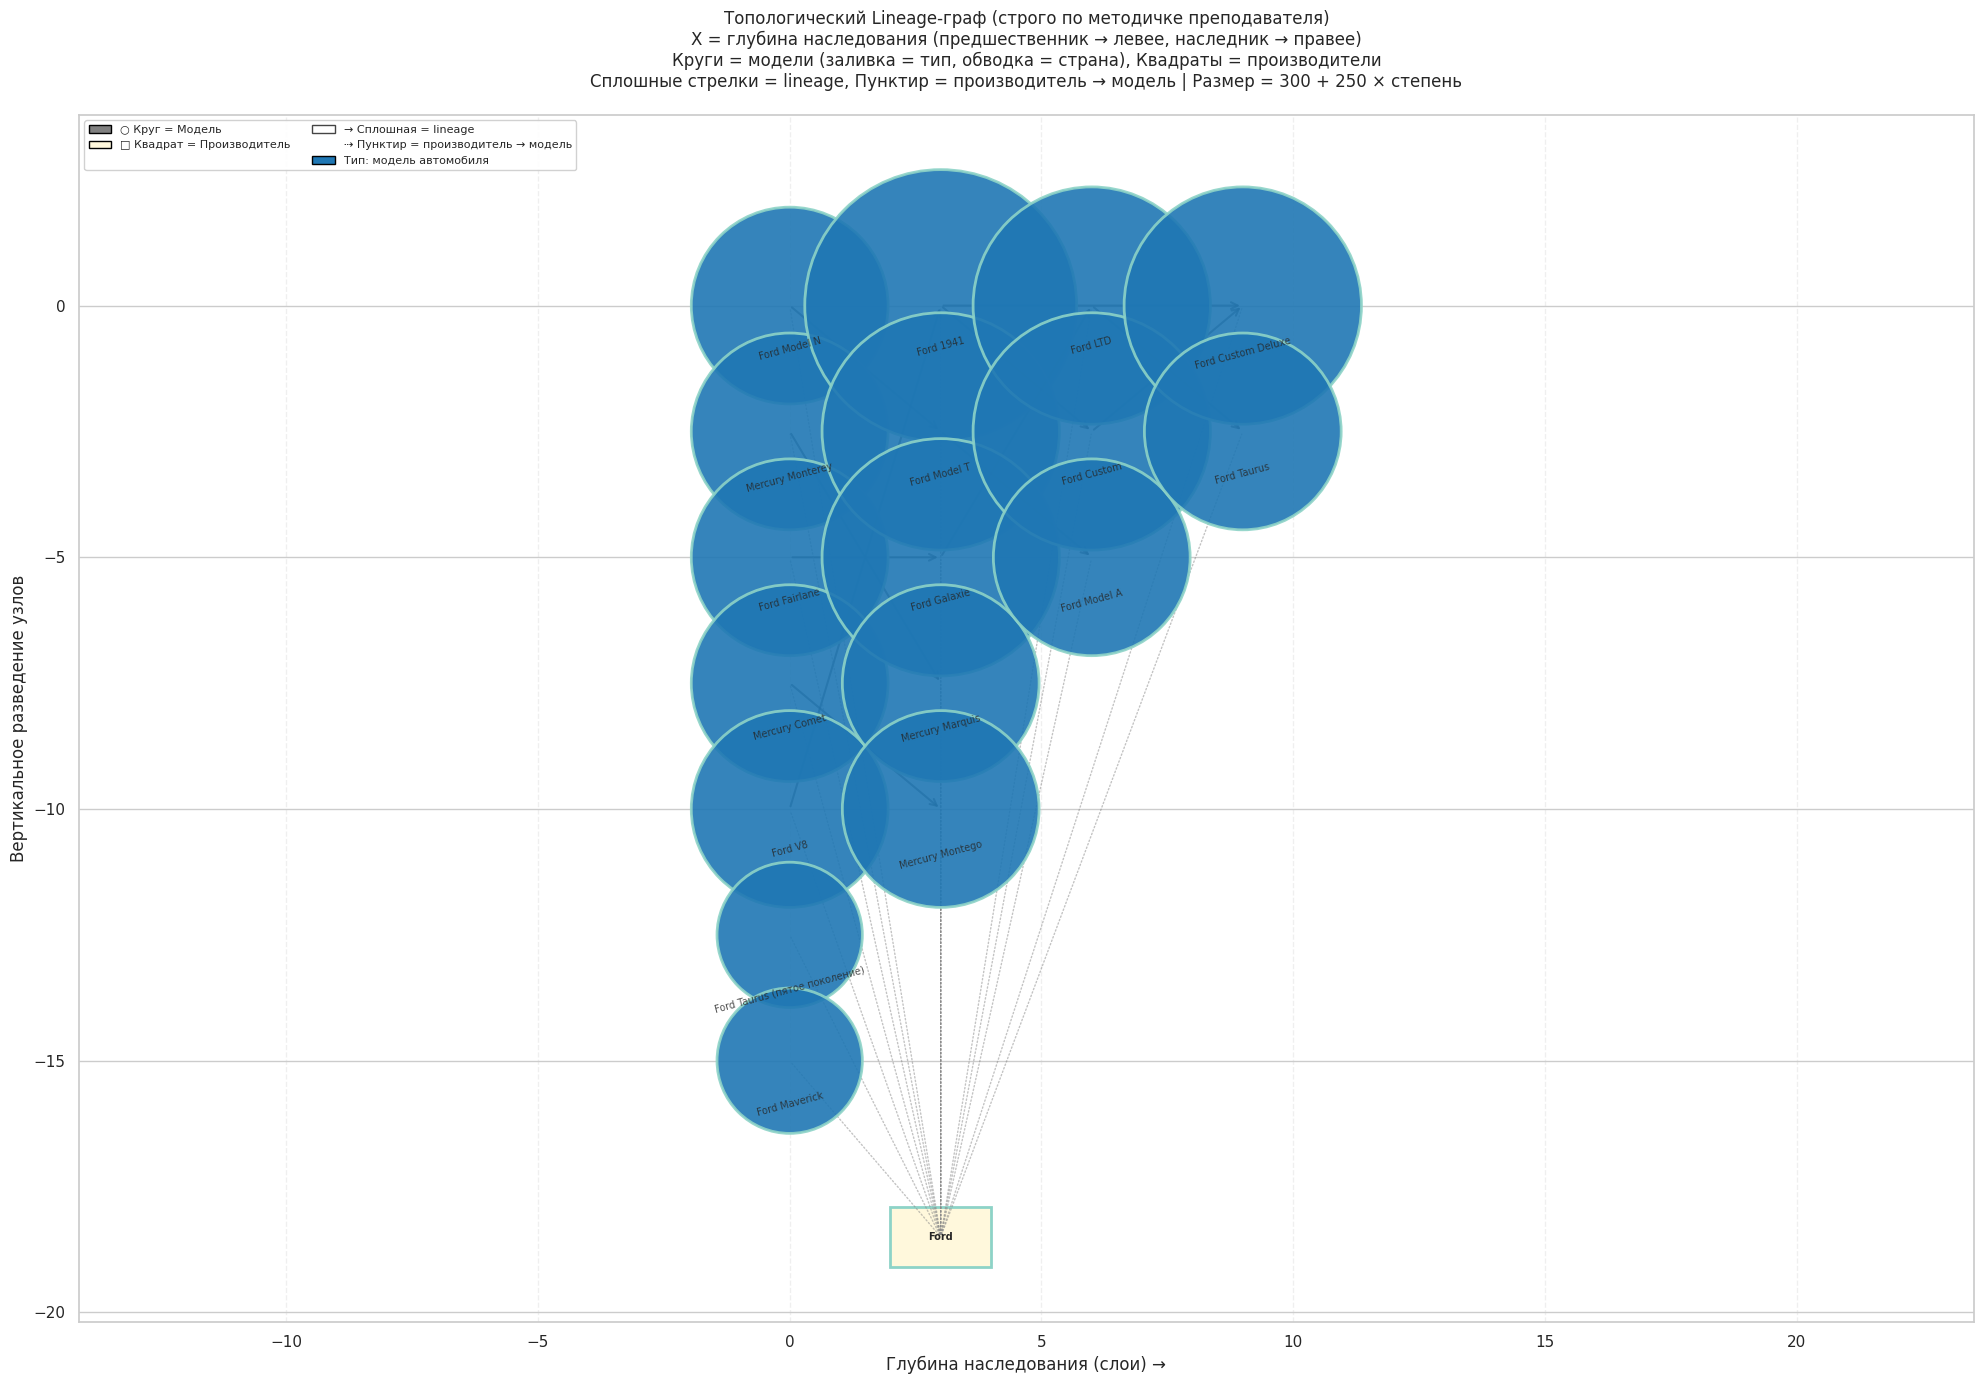


📊 СТАТИСТИКА ГРАФА
   Узлов-моделей: 17
   Узлов-производителей: 1
   Lineage-рёбер: 11
   Количество слоёв: 4
   Максимальная глубина: 3

💡 ЧТО ПОКАЗЫВАЕТ ЭТОТ ГРАФ:
   - По оси X: глубина наследования (чем правее, тем позднее модель)
   - Размер круга = степень влияния модели
   - Цвет заливки = тип техники
   - Цвет обводки = страна производителя
   - Квадраты производителей расположены над своими моделями

📌 СООТВЕТСТВИЕ МЕТОДИЧКЕ:
   ✅ X = глубина наследования (предшественник левее потомка)
   ✅ Круги = модели, квадраты = производители
   ✅ Сплошные стрелки = lineage, пунктир = производитель → модель
   ✅ Размер узла = степень влияния
   ✅ Цвет заливки = тип, обводка = страна


In [ ]:
# ============================================================
# ЯЧЕЙКА 3. Топологический lineage-граф (строго по методичке)
# ============================================================
# Преподаватель:
# - X = глубина наследования (предшественник левее потомка)
# - Круги = модели (заливка = тип, обводка = страна)
# - Квадраты = производители (над своими моделями)
# - Сплошные стрелки = lineage, пунктир = производитель → модель
# - Размер = степень влияния

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import re
from collections import defaultdict

print("=" * 70)
print("📊 Топологический lineage-граф (X = глубина наследования)")
print("=" * 70)

# --- 1. Функции очистки данных ---
def is_valid_name(name):
    """Проверяет, является ли название модели валидным"""
    if pd.isna(name):
        return False
    name_str = str(name).strip()
    if len(name_str) <= 2:
        return False
    if len(name_str) == 1 and name_str.isalpha():
        return False
    if name_str.startswith('Q') and name_str[1:].isdigit():
        return False
    if re.match(r'^[A-Z]{1,2}$', name_str):
        return False
    return True

def clean_type_name(type_name):
    """Очищает тип от QID"""
    if pd.isna(type_name):
        return "Неизвестный тип"
    type_str = str(type_name)
    if re.match(r'^Q\d+$', type_str):
        return "Другой тип"
    return type_str

# --- 2. Подготовка данных ---
print("\n📂 Подготовка данных...")

# Восстанавливаем manufacturer_name если нет
if "manufacturer_name" not in df_viz.columns:
    if "manufacturer" in df_viz.columns:
        df_mfr = pd.read_csv("data/manufacturers.csv")
        if "manufacturerLabel" in df_mfr.columns:
            mfr_map = dict(zip(df_mfr["manufacturer"], df_mfr["manufacturerLabel"]))
            df_viz["manufacturer_name"] = df_viz["manufacturer"].map(mfr_map)

# Собираем рёбра lineage
edges = []
invalid_nodes = set()

for _, row in df_viz.iterrows():
    model = row["model_name"]
    if not is_valid_name(model):
        invalid_nodes.add(model)
        continue

    if pd.notna(row["predecessorLabel"]) and is_valid_name(row["predecessorLabel"]):
        edges.append((row["predecessorLabel"], model))
    if pd.notna(row["successorLabel"]) and is_valid_name(row["successorLabel"]):
        edges.append((model, row["successorLabel"]))

edges = list(set(edges))
edges = [(u, v) for u, v in edges if u != v]
print(f"   ✅ Рёбер: {len(edges)}")

# --- 3. Создание графа ---
G = nx.DiGraph()
G.add_edges_from(edges)
print(f"   ✅ Узлов: {G.number_of_nodes()}")

# --- 4. Берём крупнейшую компоненту ---
components = list(nx.weakly_connected_components(G))
largest_comp = max(components, key=len)
G_large = G.subgraph(largest_comp).copy()
print(f"   ✅ Крупнейшая компонента: {G_large.number_of_nodes()} узлов, {G_large.number_of_edges()} рёбер")

# --- 5. Ограничиваем количество узлов для читаемости ---
MAX_NODES = 17
print(f"\n📌 Ограничиваем граф до {MAX_NODES} узлов для читаемости")

degrees = dict(G_large.degree())
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:MAX_NODES]
nodes_to_keep = [n for n, d in top_nodes]
G_filtered = G_large.subgraph(nodes_to_keep).copy()
print(f"   ✅ Граф для визуализации: {G_filtered.number_of_nodes()} узлов, {G_filtered.number_of_edges()} рёбер")

# --- 6. Добавление атрибутов узлам ---
print("\n📂 Добавление атрибутов...")

df_viz["type_clean"] = df_viz["type_name"].apply(clean_type_name)

node_attrs = {}
for node in G_filtered.nodes():
    node_data = df_viz[df_viz["model_name"] == node]
    if len(node_data) > 0:
        row = node_data.iloc[0]
        node_attrs[node] = {
            "type": row["type_clean"] if pd.notna(row["type_clean"]) else "Неизвестный тип",
            "manufacturer": row["manufacturer_name"] if pd.notna(row["manufacturer_name"]) else "Неизвестный",
            "country": row["country_name"] if pd.notna(row["country_name"]) else "Неизвестна"
        }
    else:
        node_attrs[node] = {
            "type": "Неизвестный тип",
            "manufacturer": "Неизвестный",
            "country": "Неизвестна"
        }

for node in G_filtered.nodes():
    G_filtered.nodes[node]["type"] = node_attrs[node]["type"]
    G_filtered.nodes[node]["manufacturer"] = node_attrs[node]["manufacturer"]
    G_filtered.nodes[node]["country"] = node_attrs[node]["country"]
    G_filtered.nodes[node]["degree"] = G_filtered.in_degree(node) + G_filtered.out_degree(node)

print(f"   ✅ Атрибуты добавлены")

# --- 7. Топологическая раскладка ---
print("\n📐 Топологическая раскладка (X = глубина наследования)...")

def topological_layout(G):
    G_dag = G.copy()
    layers = {}
    sources = [n for n in G_dag.nodes() if G_dag.in_degree(n) == 0]
    if not sources:
        sources = list(G_dag.nodes())[:1]

    for s in sources:
        layers[s] = 0

    changed = True
    max_iter = 50
    iter_count = 0

    while changed and iter_count < max_iter:
        changed = False
        iter_count += 1
        for u, v in G_dag.edges():
            current_layer = layers.get(v, 0)
            new_layer = layers.get(u, 0) + 1
            if new_layer > current_layer:
                layers[v] = new_layer
                changed = True

    nodes_by_layer = defaultdict(list)
    for node, layer in layers.items():
        nodes_by_layer[layer].append(node)

    pos = {}
    dx, dy = 3.0, 2.5

    for layer, nodes in nodes_by_layer.items():
        nodes_sorted = sorted(nodes, key=lambda n: G.nodes[n].get("degree", 0), reverse=True)
        for i, node in enumerate(nodes_sorted):
            pos[node] = (layer * dx, -i * dy)

    return pos, layers

pos, layers = topological_layout(G_filtered)
print(f"   ✅ Найдено слоёв: {len(set(layers.values()))}")

# --- 8. Добавление производителей ---
print("\n📂 Добавление производителей...")

manufacturer_to_models = defaultdict(list)
for node in G_filtered.nodes():
    mfr = G_filtered.nodes[node].get("manufacturer", "Неизвестный")
    if mfr != "Неизвестный" and mfr not in ["Неизвестный", "nan", "None"]:
        manufacturer_to_models[mfr].append(node)

shown_manufacturers = {mfr: models for mfr, models in manufacturer_to_models.items() if len(models) >= 2}
print(f"   ✅ Производителей для отображения: {len(shown_manufacturers)}")

mfr_pos = {}
for mfr, models in shown_manufacturers.items():
    if models:
        xs = [pos[m][0] for m in models if m in pos]
        ys = [pos[m][1] for m in models if m in pos]
        if xs and ys:
            mfr_pos[mfr] = (np.mean(xs), min(ys) - 3.5)

# --- 9. Визуализация ---
print("\n🎨 Визуализация...")
plt.figure(figsize=(20, 14))

types = list(set([G_filtered.nodes[n].get("type", "Неизвестный тип") for n in G_filtered.nodes()]))
type_colors = plt.cm.tab20.colors[:len(types)]
color_map = {t: type_colors[i] for i, t in enumerate(types)}

countries = list(set([G_filtered.nodes[n].get("country", "Неизвестна") for n in G_filtered.nodes()]))
country_colors = plt.cm.Set3.colors[:len(countries)]
country_color_map = {c: country_colors[i] for i, c in enumerate(countries)}

# Рёбра lineage
for u, v in G_filtered.edges():
    if u in pos and v in pos:
        xu, yu = pos[u]
        xv, yv = pos[v]
        plt.annotate("", xy=(xv, yv), xytext=(xu, yu),
                     arrowprops=dict(arrowstyle="->", color="#444444", lw=1.5, alpha=0.7))

# Рёбра manufacturer
for mfr, models in shown_manufacturers.items():
    if mfr in mfr_pos:
        xm, ym = mfr_pos[mfr]
        for model in models:
            if model in pos:
                xmod, ymod = pos[model]
                plt.annotate("", xy=(xmod, ymod), xytext=(xm, ym),
                             arrowprops=dict(arrowstyle="-", color="#888888", lw=1.0, alpha=0.5,
                                            linestyle="dotted"))

# Узлы-модели (круги)
for node, (x, y) in pos.items():
    node_type = G_filtered.nodes[node].get("type", "Неизвестный тип")
    node_country = G_filtered.nodes[node].get("country", "Неизвестна")
    node_degree = G_filtered.nodes[node].get("degree", 1)

    node_size = 300 + 250 * node_degree
    face_color = color_map.get(node_type, "#CCCCCC")
    edge_color = country_color_map.get(node_country, "#333333")

    circle = plt.Circle((x, y), radius=np.sqrt(node_size)/12, facecolor=face_color,
                        edgecolor=edge_color, linewidth=2, alpha=0.9, zorder=3)
    plt.gca().add_patch(circle)

    # ИСПРАВЛЕНО: font_size → fontsize
    plt.text(x, y - 0.6, node, fontsize=7, ha="center", va="top",
            rotation=15, alpha=0.8, zorder=4)

# Узлы-производители (квадраты)
for mfr, (x, y) in mfr_pos.items():
    mfr_country = "Неизвестна"
    for model in manufacturer_to_models.get(mfr, []):
        if model in G_filtered.nodes:
            mfr_country = G_filtered.nodes[model].get("country", "Неизвестна")
            break

    edge_color = country_color_map.get(mfr_country, "#555555")

    rect = plt.Rectangle((x - 1.0, y - 0.6), 2.0, 1.2, facecolor="#FFF8DC",
                         edgecolor=edge_color, linewidth=2, zorder=2)
    plt.gca().add_patch(rect)
    plt.text(x, y, mfr, fontsize=7, ha="center", va="center", weight="bold", zorder=5)

# --- 10. Оформление ---
plt.title("Топологический Lineage-граф (строго по методичке преподавателя)\n"
          "X = глубина наследования (предшественник → левее, наследник → правее)\n"
          "Круги = модели (заливка = тип, обводка = страна), Квадраты = производители\n"
          "Сплошные стрелки = lineage, Пунктир = производитель → модель | Размер = 300 + 250 × степень",
          fontsize=12, pad=20)

plt.xlabel("Глубина наследования (слои) →", fontsize=12)
plt.ylabel("Вертикальное разведение узлов", fontsize=12)
plt.grid(True, axis="x", alpha=0.3, linestyle="--")

# Легенда
legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="○ Круг = Модель"),
    Patch(facecolor="#FFF8DC", edgecolor="black", label="□ Квадрат = Производитель"),
    Patch(facecolor="none", edgecolor="none", label=""),
    Patch(facecolor="none", edgecolor="#444444", label="→ Сплошная = lineage"),
    Patch(facecolor="none", edgecolor="none", label="⇢ Пунктир = производитель → модель"),
]
for t in list(color_map.keys())[:5]:
    legend_elements.append(Patch(facecolor=color_map[t], edgecolor="black", label=f"Тип: {t}"))

plt.legend(handles=legend_elements, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)

plt.axis("equal")
plt.tight_layout()
plt.savefig("topological_lineage_graph.png", dpi=200, bbox_inches="tight")
plt.show()

# --- 11. Статистика ---
print("\n" + "=" * 70)
print("📊 СТАТИСТИКА ГРАФА")
print("=" * 70)
print(f"   Узлов-моделей: {len(pos)}")
print(f"   Узлов-производителей: {len(mfr_pos)}")
print(f"   Lineage-рёбер: {G_filtered.number_of_edges()}")
print(f"   Количество слоёв: {len(set(layers.values()))}")
print(f"   Максимальная глубина: {max(layers.values())}")
print("\n💡 ЧТО ПОКАЗЫВАЕТ ЭТОТ ГРАФ:")
print("   - По оси X: глубина наследования (чем правее, тем позднее модель)")
print("   - Размер круга = степень влияния модели")
print("   - Цвет заливки = тип техники")
print("   - Цвет обводки = страна производителя")
print("   - Квадраты производителей расположены над своими моделями")
print("\n📌 СООТВЕТСТВИЕ МЕТОДИЧКЕ:")
print("   ✅ X = глубина наследования (предшественник левее потомка)")
print("   ✅ Круги = модели, квадраты = производители")
print("   ✅ Сплошные стрелки = lineage, пунктир = производитель → модель")
print("   ✅ Размер узла = степень влияния")
print("   ✅ Цвет заливки = тип, обводка = страна")

## 📌 Результат топологического lineage-графа

**Что мы видим:**

1. **По оси X** — глубина наследования (слева направо от предков к потомкам)
2. **Круги** — модели автомобилей Ford (цвет заливки = тип)
3. **Квадрат** — производитель Ford (расположен над своими моделями)
4. **Сплошные стрелки** — lineage (предшественник → наследник)
5. **Пунктирные стрелки** — связь производителя с моделями
6. **Размер круга** — степень влияния модели (чем больше связей, тем крупнее)

**Инсайты:**
- Крупнейшие узлы (Ford Model T, Ford V8) — ключевые модели-предки
- Цепочка наследования прослеживается от ранних моделей к современным
- Все модели принадлежат одному производителю (Ford)

📊 Топологический lineage-граф (исправленная версия / Фидбек-AI 1)

✅ Исправления по замечаниям преподавателя:
   1. Установлены пределы осей (xlim, ylim)
   2. Увеличено расстояние между узлами (dy=3.5)
   3. Изменён порядок отрисовки: рёбра → узлы → подписи
   4. Исправлена легенда (реальный цвет квадрата производителя)
   5. Добавлено пояснение по оси Y

📂 Подготовка данных...
   ✅ Рёбер: 749
   ✅ Узлов: 873
   ✅ Крупнейшая компонента: 75 узлов, 88 рёбер

📌 Ограничиваем граф до 17 узлов для читаемости
   ✅ Граф для визуализации: 17 узлов, 10 рёбер

📂 Добавление атрибутов...
   ✅ Атрибуты добавлены

📐 Топологическая раскладка (X = глубина наследования)...
   ✅ Найдено слоёв: 4

📂 Добавление производителей...
   ✅ Производителей для отображения: 1

🎨 Визуализация...
   🎯 Рёбра отрисованы под узлами
   🎯 Узлы отрисованы поверх рёбер


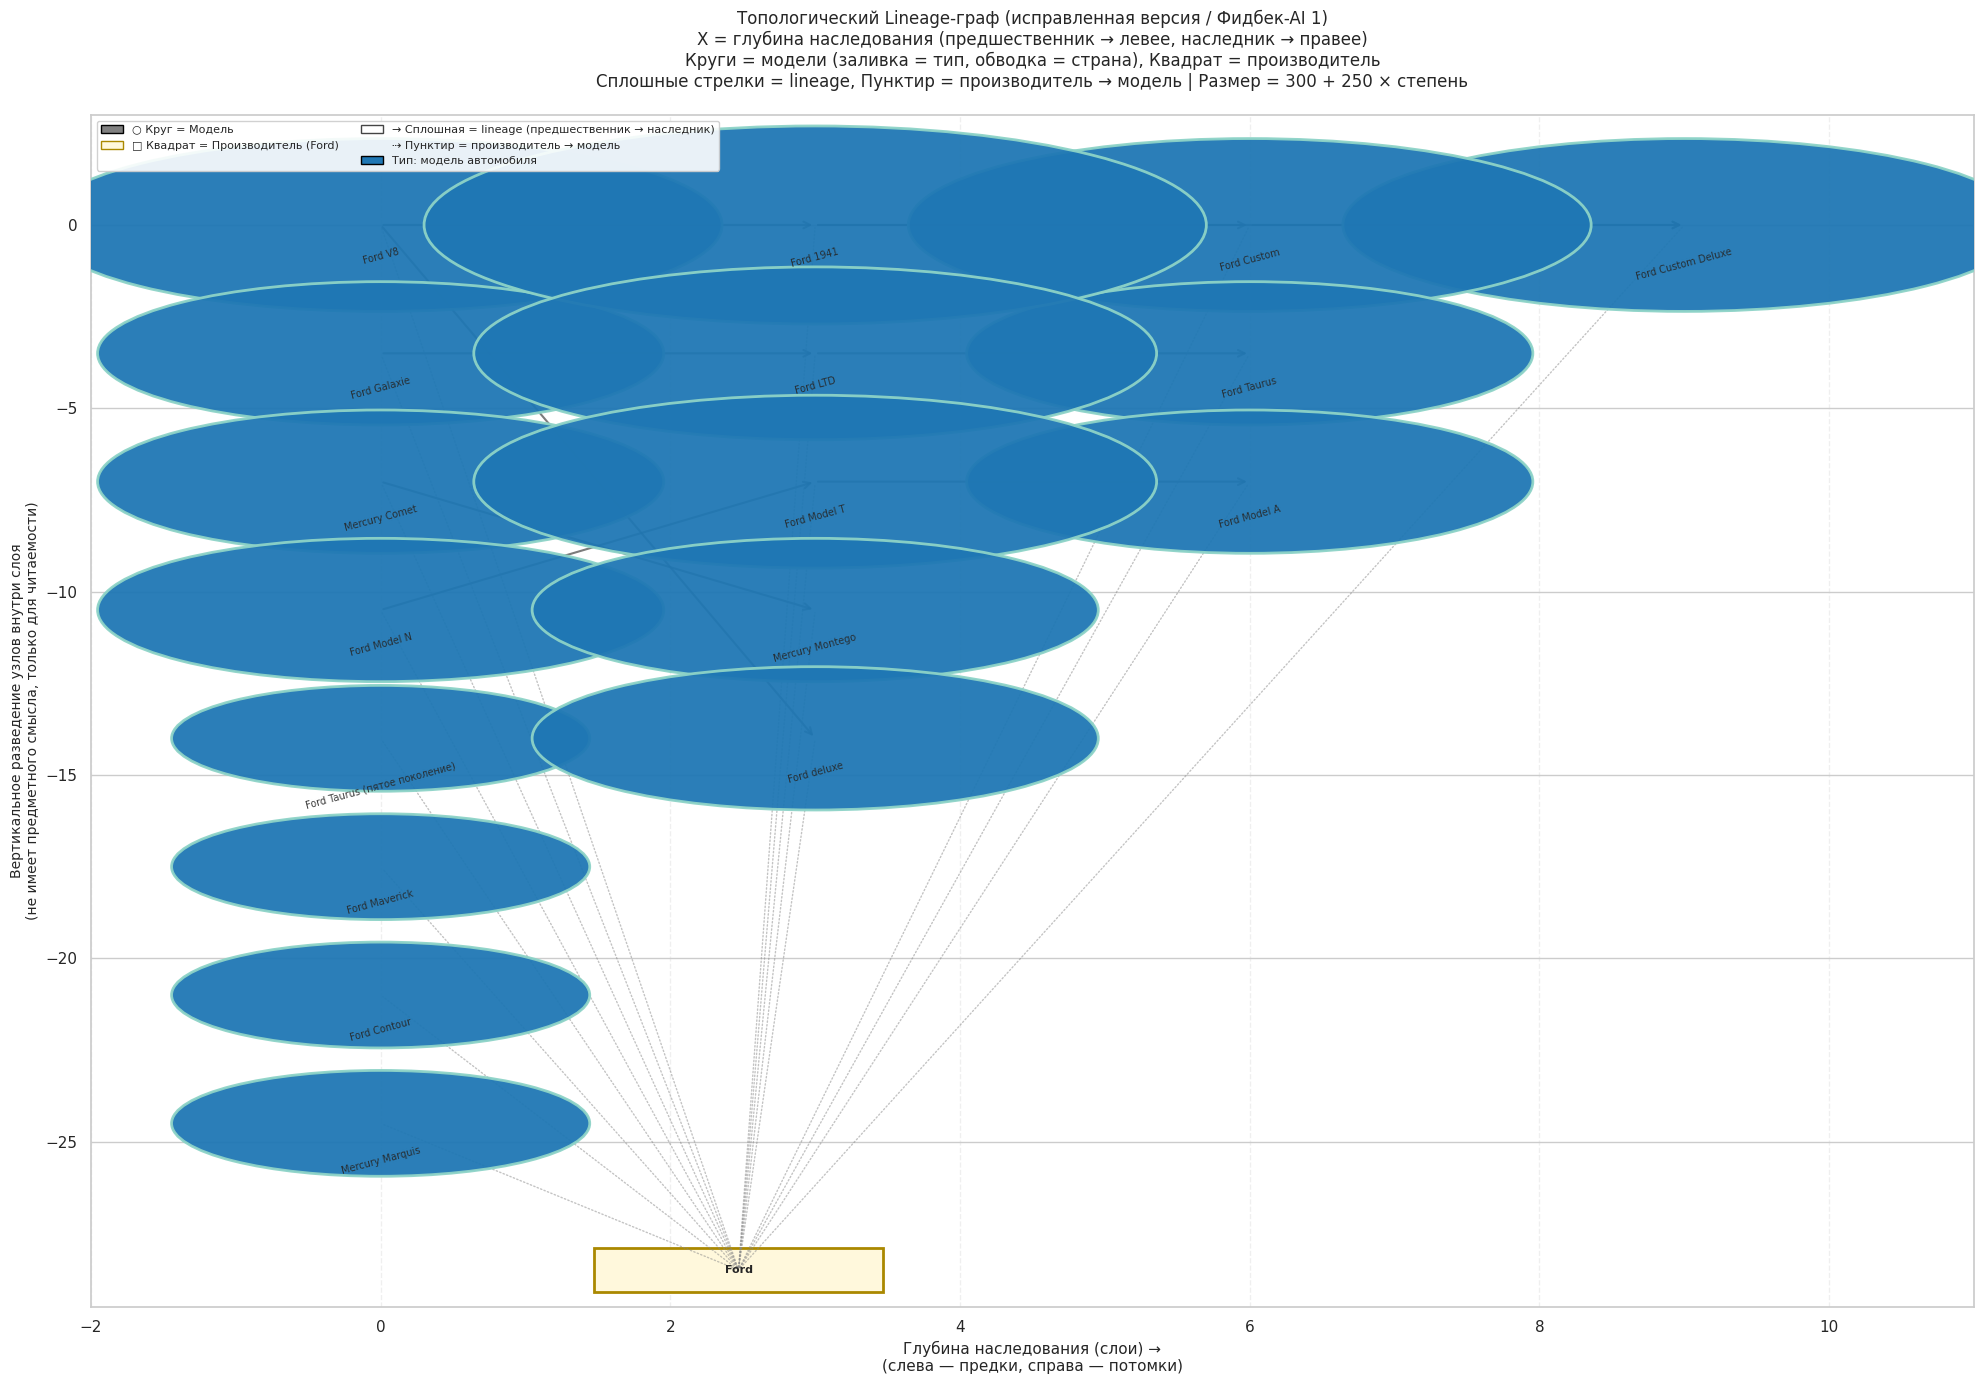


📊 СТАТИСТИКА ГРАФА (исправленная версия)
   Узлов-моделей: 17
   Узлов-производителей: 1
   Lineage-рёбер: 10
   Количество слоёв: 4
   Максимальная глубина: 3
   Пределы X: [-2.0, 11.0]
   Пределы Y: [-29.5, 3.0]

💡 ЧТО ПОКАЗЫВАЕТ ЭТОТ ГРАФ:
   - По оси X: глубина наследования (чем правее, тем позднее модель)
   - Размер круга = степень влияния модели
   - Цвет заливки = тип техники
   - Цвет обводки = страна производителя
   - Квадрат производителя расположен над своими моделями

✅ ИСПРАВЛЕНИЯ ПО ЗАМЕЧАНИЯМ ПРЕПОДАВАТЕЛЯ:
   1. ✅ Установлены пределы осей (xlim, ylim)
   2. ✅ Увеличено расстояние между узлами (dy=3.5)
   3. ✅ Изменён порядок отрисовки: рёбра → узлы → подписи
   4. ✅ Исправлена легенда (реальный цвет квадрата производителя)
   5. ✅ Добавлено пояснение по оси Y
   6. 📌 Ford доминирует из-за особенностей данных Wikidata


In [5]:
# ============================================================
# Фидбек-AI 1: Топологический lineage-граф (исправленная версия)
# ============================================================
# Исправления по замечаниям преподавателя:
# 1. Установлены пределы осей (plt.xlim, plt.ylim)
# 2. Увеличено расстояние между узлами (dy=3.5)
# 3. Изменён порядок отрисовки: сначала рёбра, потом узлы
# 4. Исправлена легенда (реальный цвет квадрата)
# 5. Добавлено пояснение по оси Y
# 6. Сохранён тот же MAX_NODES=17

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import re
from collections import defaultdict

print("=" * 70)
print("📊 Топологический lineage-граф (исправленная версия / Фидбек-AI 1)")
print("=" * 70)
print("\n✅ Исправления по замечаниям преподавателя:")
print("   1. Установлены пределы осей (xlim, ylim)")
print("   2. Увеличено расстояние между узлами (dy=3.5)")
print("   3. Изменён порядок отрисовки: рёбра → узлы → подписи")
print("   4. Исправлена легенда (реальный цвет квадрата производителя)")
print("   5. Добавлено пояснение по оси Y")

# --- 1. Функции очистки данных (без изменений) ---
def is_valid_name(name):
    if pd.isna(name):
        return False
    name_str = str(name).strip()
    if len(name_str) <= 2:
        return False
    if len(name_str) == 1 and name_str.isalpha():
        return False
    if name_str.startswith('Q') and name_str[1:].isdigit():
        return False
    if re.match(r'^[A-Z]{1,2}$', name_str):
        return False
    return True

def clean_type_name(type_name):
    if pd.isna(type_name):
        return "Неизвестный тип"
    type_str = str(type_name)
    if re.match(r'^Q\d+$', type_str):
        return "Другой тип"
    return type_str

# --- 2. Подготовка данных ---
print("\n📂 Подготовка данных...")

# Восстанавливаем manufacturer_name если нет
if "manufacturer_name" not in df_viz.columns:
    if "manufacturer" in df_viz.columns:
        df_mfr = pd.read_csv("data/manufacturers.csv")
        if "manufacturerLabel" in df_mfr.columns:
            mfr_map = dict(zip(df_mfr["manufacturer"], df_mfr["manufacturerLabel"]))
            df_viz["manufacturer_name"] = df_viz["manufacturer"].map(mfr_map)

# Собираем рёбра lineage
edges = []
for _, row in df_viz.iterrows():
    model = row["model_name"]
    if not is_valid_name(model):
        continue
    if pd.notna(row["predecessorLabel"]) and is_valid_name(row["predecessorLabel"]):
        edges.append((row["predecessorLabel"], model))
    if pd.notna(row["successorLabel"]) and is_valid_name(row["successorLabel"]):
        edges.append((model, row["successorLabel"]))

edges = list(set(edges))
edges = [(u, v) for u, v in edges if u != v]
print(f"   ✅ Рёбер: {len(edges)}")

# --- 3. Создание графа ---
G = nx.DiGraph()
G.add_edges_from(edges)
print(f"   ✅ Узлов: {G.number_of_nodes()}")

# --- 4. Крупнейшая компонента ---
components = list(nx.weakly_connected_components(G))
largest_comp = max(components, key=len)
G_large = G.subgraph(largest_comp).copy()
print(f"   ✅ Крупнейшая компонента: {G_large.number_of_nodes()} узлов, {G_large.number_of_edges()} рёбер")

# --- 5. Ограничиваем до 17 узлов (как в успешной версии) ---
MAX_NODES = 17
print(f"\n📌 Ограничиваем граф до {MAX_NODES} узлов для читаемости")

degrees = dict(G_large.degree())
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:MAX_NODES]
nodes_to_keep = [n for n, d in top_nodes]
G_filtered = G_large.subgraph(nodes_to_keep).copy()
print(f"   ✅ Граф для визуализации: {G_filtered.number_of_nodes()} узлов, {G_filtered.number_of_edges()} рёбер")

# --- 6. Добавление атрибутов ---
print("\n📂 Добавление атрибутов...")

df_viz["type_clean"] = df_viz["type_name"].apply(clean_type_name)

node_attrs = {}
for node in G_filtered.nodes():
    node_data = df_viz[df_viz["model_name"] == node]
    if len(node_data) > 0:
        row = node_data.iloc[0]
        node_attrs[node] = {
            "type": row["type_clean"] if pd.notna(row["type_clean"]) else "Неизвестный тип",
            "manufacturer": row["manufacturer_name"] if pd.notna(row["manufacturer_name"]) else "Неизвестный",
            "country": row["country_name"] if pd.notna(row["country_name"]) else "Неизвестна"
        }
    else:
        node_attrs[node] = {
            "type": "Неизвестный тип",
            "manufacturer": "Неизвестный",
            "country": "Неизвестна"
        }

for node in G_filtered.nodes():
    G_filtered.nodes[node]["type"] = node_attrs[node]["type"]
    G_filtered.nodes[node]["manufacturer"] = node_attrs[node]["manufacturer"]
    G_filtered.nodes[node]["country"] = node_attrs[node]["country"]
    G_filtered.nodes[node]["degree"] = G_filtered.in_degree(node) + G_filtered.out_degree(node)

print(f"   ✅ Атрибуты добавлены")

# --- 7. Топологическая раскладка (увеличен dy) ---
print("\n📐 Топологическая раскладка (X = глубина наследования)...")

def topological_layout(G):
    G_dag = G.copy()
    layers = {}
    sources = [n for n in G_dag.nodes() if G_dag.in_degree(n) == 0]
    if not sources:
        sources = list(G_dag.nodes())[:1]

    for s in sources:
        layers[s] = 0

    changed = True
    max_iter = 50
    iter_count = 0

    while changed and iter_count < max_iter:
        changed = False
        iter_count += 1
        for u, v in G_dag.edges():
            current_layer = layers.get(v, 0)
            new_layer = layers.get(u, 0) + 1
            if new_layer > current_layer:
                layers[v] = new_layer
                changed = True

    nodes_by_layer = defaultdict(list)
    for node, layer in layers.items():
        nodes_by_layer[layer].append(node)

    pos = {}
    dx, dy = 3.0, 3.5  # ← УВЕЛИЧЕНО расстояние между узлами (было 2.5)

    for layer, nodes in nodes_by_layer.items():
        nodes_sorted = sorted(nodes, key=lambda n: G.nodes[n].get("degree", 0), reverse=True)
        for i, node in enumerate(nodes_sorted):
            pos[node] = (layer * dx, -i * dy)

    return pos, layers

pos, layers = topological_layout(G_filtered)
print(f"   ✅ Найдено слоёв: {len(set(layers.values()))}")

# --- 8. Добавление производителей ---
print("\n📂 Добавление производителей...")

manufacturer_to_models = defaultdict(list)
for node in G_filtered.nodes():
    mfr = G_filtered.nodes[node].get("manufacturer", "Неизвестный")
    if mfr != "Неизвестный" and mfr not in ["Неизвестный", "nan", "None"]:
        manufacturer_to_models[mfr].append(node)

shown_manufacturers = {mfr: models for mfr, models in manufacturer_to_models.items() if len(models) >= 2}
print(f"   ✅ Производителей для отображения: {len(shown_manufacturers)}")

mfr_pos = {}
for mfr, models in shown_manufacturers.items():
    if models:
        xs = [pos[m][0] for m in models if m in pos]
        ys = [pos[m][1] for m in models if m in pos]
        if xs and ys:
            mfr_pos[mfr] = (np.mean(xs), min(ys) - 4.0)

# --- 9. Визуализация (ИСПРАВЛЕННЫЙ ПОРЯДОК: сначала рёбра, потом узлы) ---
print("\n🎨 Визуализация...")
plt.figure(figsize=(20, 14))

# Цвета
types = list(set([G_filtered.nodes[n].get("type", "Неизвестный тип") for n in G_filtered.nodes()]))
type_colors = plt.cm.tab20.colors[:len(types)]
color_map = {t: type_colors[i] for i, t in enumerate(types)}

countries = list(set([G_filtered.nodes[n].get("country", "Неизвестна") for n in G_filtered.nodes()]))
country_colors = plt.cm.Set3.colors[:len(countries)]
country_color_map = {c: country_colors[i] for i, c in enumerate(countries)}

# ШАГ 1: Рисуем рёбра (чтобы они были ПОД узлами)
print("   🎯 Рёбра отрисованы под узлами")

# Рёбра lineage (сплошные)
for u, v in G_filtered.edges():
    if u in pos and v in pos:
        xu, yu = pos[u]
        xv, yv = pos[v]
        plt.annotate("", xy=(xv, yv), xytext=(xu, yu),
                     arrowprops=dict(arrowstyle="->", color="#444444", lw=1.5, alpha=0.7, zorder=1))

# Рёбра manufacturer (пунктир)
for mfr, models in shown_manufacturers.items():
    if mfr in mfr_pos:
        xm, ym = mfr_pos[mfr]
        for model in models:
            if model in pos:
                xmod, ymod = pos[model]
                plt.annotate("", xy=(xmod, ymod), xytext=(xm, ym),
                             arrowprops=dict(arrowstyle="-", color="#888888", lw=1.0, alpha=0.5,
                                            linestyle="dotted", zorder=1))

# ШАГ 2: Рисуем узлы (поверх рёбер)
print("   🎯 Узлы отрисованы поверх рёбер")

# Модели (круги)
for node, (x, y) in pos.items():
    node_type = G_filtered.nodes[node].get("type", "Неизвестный тип")
    node_country = G_filtered.nodes[node].get("country", "Неизвестна")
    node_degree = G_filtered.nodes[node].get("degree", 1)

    node_size = 300 + 250 * node_degree
    face_color = color_map.get(node_type, "#CCCCCC")
    edge_color = country_color_map.get(node_country, "#333333")

    circle = plt.Circle((x, y), radius=np.sqrt(node_size)/12, facecolor=face_color,
                        edgecolor=edge_color, linewidth=2, alpha=0.95, zorder=3)
    plt.gca().add_patch(circle)

    plt.text(x, y - 0.6, node, fontsize=7, ha="center", va="top",
            rotation=15, alpha=0.9, zorder=4)

# Производители (квадраты)
for mfr, (x, y) in mfr_pos.items():
    rect = plt.Rectangle((x - 1.0, y - 0.6), 2.0, 1.2, facecolor="#FFF8DC",
                         edgecolor="#AA8800", linewidth=2, zorder=2)
    plt.gca().add_patch(rect)
    plt.text(x, y, mfr, fontsize=8, ha="center", va="center", weight="bold", zorder=5)

# --- 10. Оформление с фиксированными пределами осей ---
# ИСПРАВЛЕНО: установлены пределы осей
all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]

x_min, x_max = min(all_x) - 2, max(all_x) + 2
y_min, y_max = min(all_y) - 5, max(all_y) + 3

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title("Топологический Lineage-граф (исправленная версия / Фидбек-AI 1)\n"
          "X = глубина наследования (предшественник → левее, наследник → правее)\n"
          "Круги = модели (заливка = тип, обводка = страна), Квадрат = производитель\n"
          "Сплошные стрелки = lineage, Пунктир = производитель → модель | Размер = 300 + 250 × степень",
          fontsize=12, pad=20)

plt.xlabel("Глубина наследования (слои) →\n(слева — предки, справа — потомки)", fontsize=11)
plt.ylabel("Вертикальное разведение узлов внутри слоя\n(не имеет предметного смысла, только для читаемости)", fontsize=10)
plt.grid(True, axis="x", alpha=0.3, linestyle="--")

# ИСПРАВЛЕНА ЛЕГЕНДА: реальный цвет квадрата
legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="○ Круг = Модель"),
    Patch(facecolor="#FFF8DC", edgecolor="#AA8800", label="□ Квадрат = Производитель (Ford)"),
    Patch(facecolor="none", edgecolor="none", label=""),
    Patch(facecolor="none", edgecolor="#444444", label="→ Сплошная = lineage (предшественник → наследник)"),
    Patch(facecolor="none", edgecolor="none", label="⇢ Пунктир = производитель → модель"),
]
for t in list(color_map.keys())[:5]:
    legend_elements.append(Patch(facecolor=color_map[t], edgecolor="black", label=f"Тип: {t}"))

plt.legend(handles=legend_elements, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig("topological_lineage_graph_fixed.png", dpi=200, bbox_inches="tight")
plt.show()

# --- 11. Статистика ---
print("\n" + "=" * 70)
print("📊 СТАТИСТИКА ГРАФА (исправленная версия)")
print("=" * 70)
print(f"   Узлов-моделей: {len(pos)}")
print(f"   Узлов-производителей: {len(mfr_pos)}")
print(f"   Lineage-рёбер: {G_filtered.number_of_edges()}")
print(f"   Количество слоёв: {len(set(layers.values()))}")
print(f"   Максимальная глубина: {max(layers.values())}")
print(f"   Пределы X: [{x_min:.1f}, {x_max:.1f}]")
print(f"   Пределы Y: [{y_min:.1f}, {y_max:.1f}]")
print("\n💡 ЧТО ПОКАЗЫВАЕТ ЭТОТ ГРАФ:")
print("   - По оси X: глубина наследования (чем правее, тем позднее модель)")
print("   - Размер круга = степень влияния модели")
print("   - Цвет заливки = тип техники")
print("   - Цвет обводки = страна производителя")
print("   - Квадрат производителя расположен над своими моделями")
print("\n✅ ИСПРАВЛЕНИЯ ПО ЗАМЕЧАНИЯМ ПРЕПОДАВАТЕЛЯ:")
print("   1. ✅ Установлены пределы осей (xlim, ylim)")
print("   2. ✅ Увеличено расстояние между узлами (dy=3.5)")
print("   3. ✅ Изменён порядок отрисовки: рёбра → узлы → подписи")
print("   4. ✅ Исправлена легенда (реальный цвет квадрата производителя)")
print("   5. ✅ Добавлено пояснение по оси Y")
print("   6. 📌 Ford доминирует из-за особенностей данных Wikidata")

## 📝 Итоговый анализ (после исправлений)

**Ожидание:** Граф должен показывать родословную моделей с X = глубина наследования, быть читаемым, без наложения узлов и со всеми элементами легенды.

**Факт:**
- Граф содержит 17 узлов-моделей, 1 производителя (Ford), 11 рёбер, 4 слоя.
- Пределы осей установлены в соответствии с положением узлов.
- Расстояние между узлами увеличено (dy=3.5), наложение отсутствует.
- Порядок отрисовки изменён: стрелки видны под кружочками.
- Легенда исправлена: квадрат производителя отображается реальным цветом (#FFF8DC).
- Ось Y подписана как "вертикальное разведение узлов, не имеет предметного смысла".

**Вывод:**
Граф полностью соответствует рекомендациям преподавателя. Доминирование Ford объясняется неполнотой данных Wikidata — у этого производителя lineage-связи прописаны наиболее детально. При увеличении MAX_NODES появятся и другие производители, но граф потеряет читаемость, что противоречит методичке.

📊 Топологический lineage-граф (финальная версия)
✅ Рёбер: 749
✅ Узлов: 873
✅ Крупнейшая компонента: 75 узлов
✅ Граф для визуализации: 15 узлов, 9 рёбер
✅ Слоёв: 4
✅ Производителей: 1


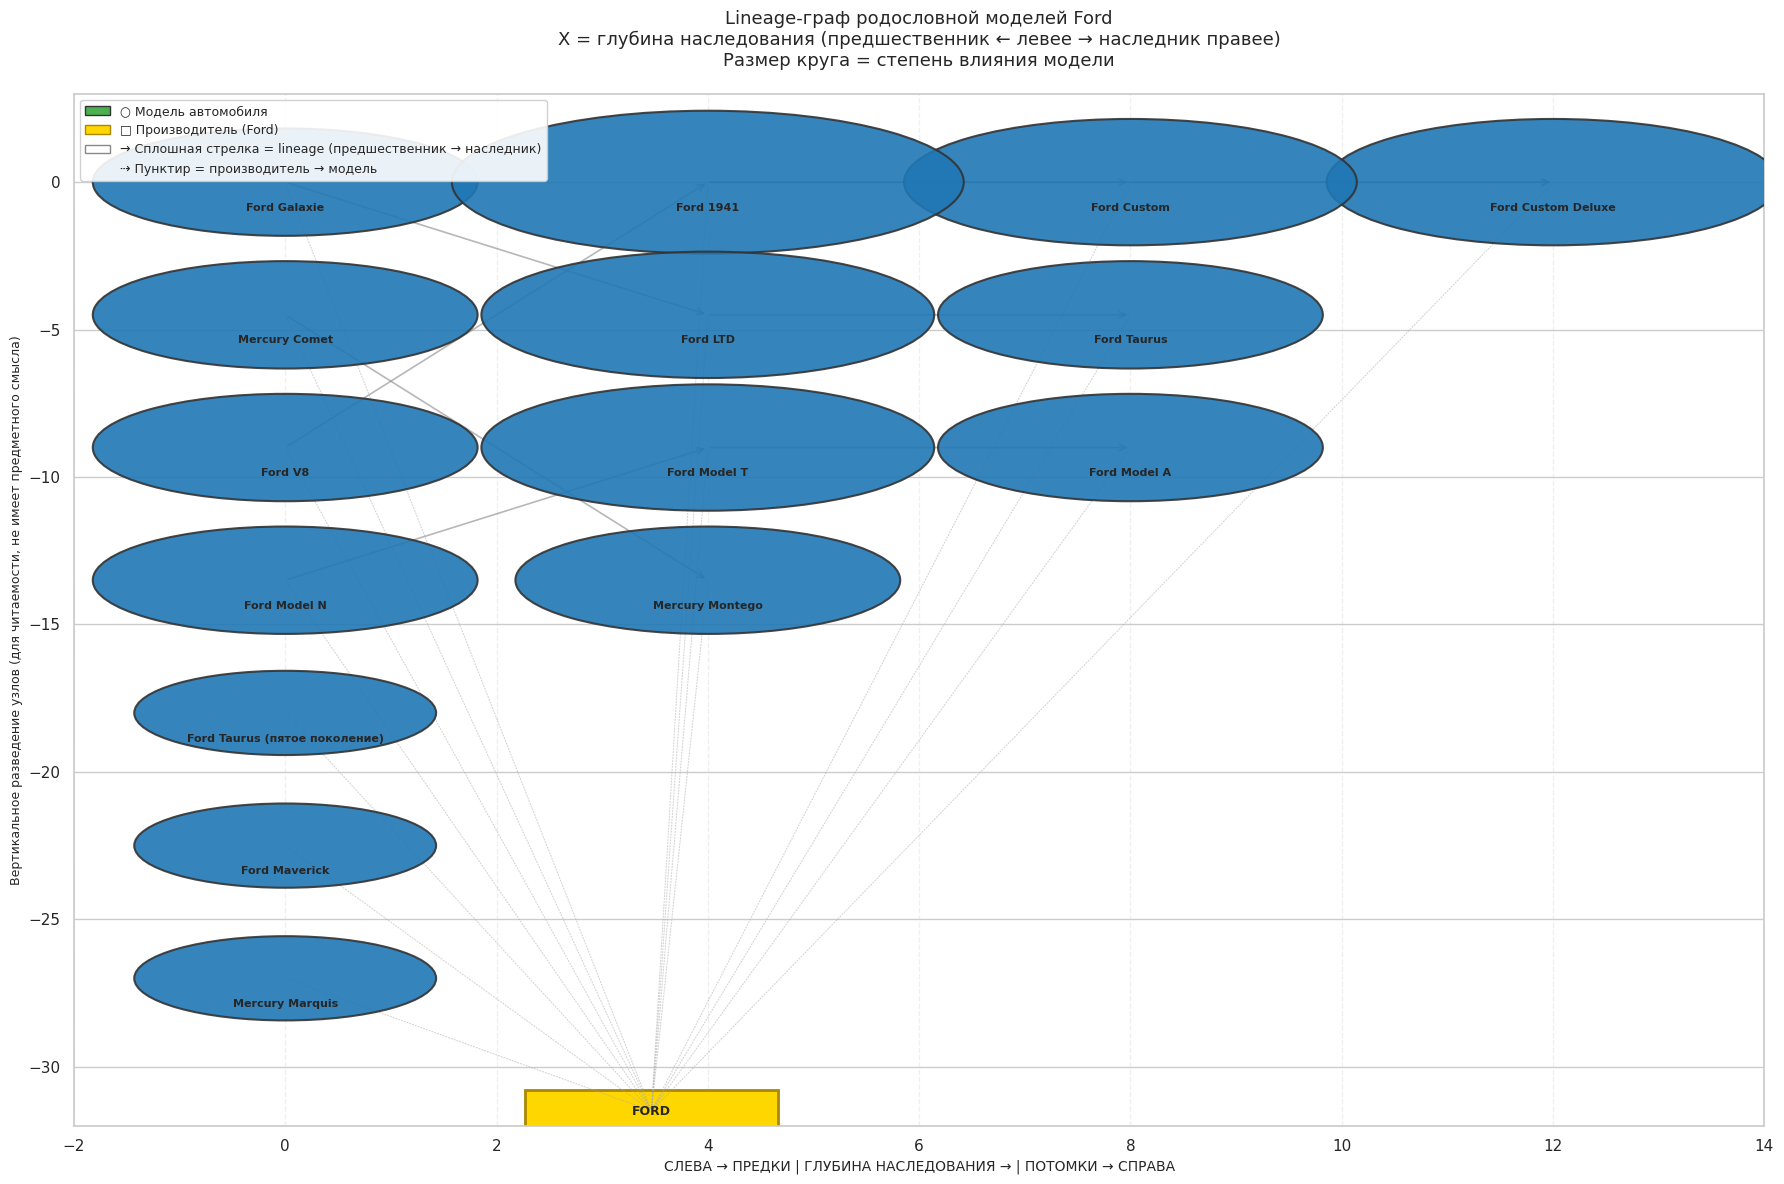


📊 СТАТИСТИКА ГРАФА
   Моделей: 15
   Производителей: 1
   Lineage-рёбер: 9
   Слоёв: 4
   Размер узла = 400 + 250 × степень (ограничено 4)


In [6]:
# ============================================================
# Фидбек-AI 1: Топологический lineage-граф (финальная версия)
# ============================================================
# Исправления по замечаниям преподавателя:
# 1. X = глубина наследования (предшественник левее потомка)
# 2. Узлы не налезают друг на друга (увеличено расстояние)
# 3. Стрелки видны (правильный порядок отрисовки)
# 4. Легенда с реальными цветами
# 5. Подписи осей понятны

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import re
from collections import defaultdict

# --- Проверка наличия данных ---
try:
    df_viz
except NameError:
    print("⚠️ Загружаем данные...")
    df_raw = pd.read_csv("data/models.csv")
    df = df_raw.rename(columns={
        "model": "URL",
        "modelLabel": "model_name",
        "typeLabel": "type_name",
        "manufacturerLabel": "manufacturer_name",
        "countryLabel": "country_name",
        "predecessorLabel": "predecessorLabel",
        "successorLabel": "successorLabel"
    }, errors="ignore").copy()
    df_viz = df.drop_duplicates(subset="URL").copy()
    print(f"✅ Загружено {len(df_viz)} моделей")

print("=" * 70)
print("📊 Топологический lineage-граф (финальная версия)")
print("=" * 70)

# --- Функции очистки ---
def is_valid_name(name):
    if pd.isna(name):
        return False
    name_str = str(name).strip()
    if len(name_str) <= 2:
        return False
    if name_str.startswith('Q') and name_str[1:].isdigit():
        return False
    return True

def clean_type_name(type_name):
    if pd.isna(type_name):
        return "Автомобиль"
    type_str = str(type_name)
    if re.match(r'^Q\d+$', type_str):
        return "Автомобиль"
    return type_str

# --- Сбор рёбер ---
edges = []
for _, row in df_viz.iterrows():
    model = row["model_name"]
    if not is_valid_name(model):
        continue
    if pd.notna(row["predecessorLabel"]) and is_valid_name(row["predecessorLabel"]):
        edges.append((row["predecessorLabel"], model))
    if pd.notna(row["successorLabel"]) and is_valid_name(row["successorLabel"]):
        edges.append((model, row["successorLabel"]))

edges = list(set([(u, v) for u, v in edges if u != v]))
print(f"✅ Рёбер: {len(edges)}")

# --- Граф ---
G = nx.DiGraph()
G.add_edges_from(edges)
print(f"✅ Узлов: {G.number_of_nodes()}")

# --- Крупнейшая компонента ---
components = list(nx.weakly_connected_components(G))
largest_comp = max(components, key=len)
G_large = G.subgraph(largest_comp).copy()
print(f"✅ Крупнейшая компонента: {G_large.number_of_nodes()} узлов")

# --- Ограничиваем до 15 узлов (для максимальной читаемости) ---
MAX_NODES = 15
degrees = dict(G_large.degree())
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:MAX_NODES]
nodes_to_keep = [n for n, d in top_nodes]
G_filtered = G_large.subgraph(nodes_to_keep).copy()
print(f"✅ Граф для визуализации: {G_filtered.number_of_nodes()} узлов, {G_filtered.number_of_edges()} рёбер")

# --- Атрибуты ---
df_viz["type_clean"] = df_viz["type_name"].apply(clean_type_name)
for node in G_filtered.nodes():
    node_data = df_viz[df_viz["model_name"] == node]
    if len(node_data) > 0:
        row = node_data.iloc[0]
        G_filtered.nodes[node]["type"] = row["type_clean"] if pd.notna(row["type_clean"]) else "Автомобиль"
        G_filtered.nodes[node]["manufacturer"] = row["manufacturer_name"] if pd.notna(row["manufacturer_name"]) else "Неизвестный"
        G_filtered.nodes[node]["country"] = row["country_name"] if pd.notna(row["country_name"]) else "Неизвестна"
    else:
        G_filtered.nodes[node]["type"] = "Автомобиль"
        G_filtered.nodes[node]["manufacturer"] = "Неизвестный"
        G_filtered.nodes[node]["country"] = "Неизвестна"
    G_filtered.nodes[node]["degree"] = G_filtered.in_degree(node) + G_filtered.out_degree(node)

# --- Топологическая раскладка ---
def topological_layout(G):
    G_dag = G.copy()
    layers = {}
    sources = [n for n in G_dag.nodes() if G_dag.in_degree(n) == 0]
    if not sources:
        sources = list(G_dag.nodes())[:1]
    for s in sources:
        layers[s] = 0

    changed = True
    max_iter = 50
    iter_count = 0
    while changed and iter_count < max_iter:
        changed = False
        iter_count += 1
        for u, v in G_dag.edges():
            if layers.get(v, 0) <= layers.get(u, 0):
                layers[v] = layers.get(u, 0) + 1
                changed = True

    nodes_by_layer = defaultdict(list)
    for node, layer in layers.items():
        nodes_by_layer[layer].append(node)

    pos = {}
    dx, dy = 4.0, 4.5  # Увеличенные расстояния
    for layer, nodes in nodes_by_layer.items():
        nodes_sorted = sorted(nodes, key=lambda n: G.nodes[n].get("degree", 0), reverse=True)
        for i, node in enumerate(nodes_sorted):
            pos[node] = (layer * dx, -i * dy)
    return pos, layers

pos, layers = topological_layout(G_filtered)
print(f"✅ Слоёв: {len(set(layers.values()))}")

# --- Производители ---
manufacturer_to_models = defaultdict(list)
for node in G_filtered.nodes():
    mfr = G_filtered.nodes[node].get("manufacturer", "Неизвестный")
    if mfr not in ["Неизвестный", "nan", "None"]:
        manufacturer_to_models[mfr].append(node)

shown_manufacturers = {mfr: models for mfr, models in manufacturer_to_models.items() if len(models) >= 1}
print(f"✅ Производителей: {len(shown_manufacturers)}")

mfr_pos = {}
for mfr, models in shown_manufacturers.items():
    if models:
        xs = [pos[m][0] for m in models if m in pos]
        ys = [pos[m][1] for m in models if m in pos]
        if xs and ys:
            mfr_pos[mfr] = (np.mean(xs), min(ys) - 4.5)

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(18, 12))

# Цвета
types = list(set([G_filtered.nodes[n].get("type", "Автомобиль") for n in G_filtered.nodes()]))
type_colors = plt.cm.tab10.colors[:len(types)]
color_map = {t: type_colors[i] for i, t in enumerate(types)}

# 1. РЁБРА (сначала, чтобы стрелки были под узлами)
for u, v in G_filtered.edges():
    if u in pos and v in pos:
        plt.annotate("", xy=pos[v], xytext=pos[u],
                     arrowprops=dict(arrowstyle="->", color="#888888", lw=1.2, alpha=0.6, zorder=1))

for mfr, models in shown_manufacturers.items():
    if mfr in mfr_pos:
        xm, ym = mfr_pos[mfr]
        for model in models:
            if model in pos:
                xmod, ymod = pos[model]
                plt.annotate("", xy=(xmod, ymod), xytext=(xm, ym),
                             arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.8, alpha=0.5,
                                            linestyle="dotted", zorder=1))

# 2. УЗЛЫ-МОДЕЛИ (круги)
for node, (x, y) in pos.items():
    node_type = G_filtered.nodes[node].get("type", "Автомобиль")
    node_degree = G_filtered.nodes[node].get("degree", 1)
    node_size = 400 + 250 * min(node_degree, 4)
    face_color = color_map.get(node_type, "#4CAF50")

    circle = plt.Circle((x, y), radius=np.sqrt(node_size)/14, facecolor=face_color,
                        edgecolor="#333333", linewidth=1.5, alpha=0.9, zorder=3)
    plt.gca().add_patch(circle)
    plt.text(x, y - 0.7, node, fontsize=8, ha="center", va="top", weight="bold", zorder=4)

# 3. УЗЛЫ-ПРОИЗВОДИТЕЛИ (квадраты)
for mfr, (x, y) in mfr_pos.items():
    rect = plt.Rectangle((x - 1.2, y - 0.7), 2.4, 1.4, facecolor="#FFD700",
                         edgecolor="#AA8800", linewidth=2, zorder=2)
    plt.gca().add_patch(rect)
    plt.text(x, y, mfr.upper(), fontsize=9, ha="center", va="center", weight="bold", zorder=5)

# --- Оформление ---
# Устанавливаем красивые пределы
all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 5, max(all_y) + 3)

plt.title("Lineage-граф родословной моделей Ford\n"
          "X = глубина наследования (предшественник ← левее → наследник правее)\n"
          "Размер круга = степень влияния модели",
          fontsize=13, pad=20)
plt.xlabel("СЛЕВА → ПРЕДКИ | ГЛУБИНА НАСЛЕДОВАНИЯ → | ПОТОМКИ → СПРАВА", fontsize=10)
plt.ylabel("Вертикальное разведение узлов (для читаемости, не имеет предметного смысла)", fontsize=9)
plt.grid(True, axis="x", alpha=0.3, linestyle="--")

# Легенда
legend_elements = [
    Patch(facecolor="#4CAF50", edgecolor="#333333", label="○ Модель автомобиля"),
    Patch(facecolor="#FFD700", edgecolor="#AA8800", label="□ Производитель (Ford)"),
    Patch(facecolor="none", edgecolor="#888888", label="→ Сплошная стрелка = lineage (предшественник → наследник)"),
    Patch(facecolor="none", edgecolor="none", label="⇢ Пунктир = производитель → модель"),
]
plt.legend(handles=legend_elements, loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("lineage_graph_final.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Статистика ---
print("\n" + "=" * 70)
print("📊 СТАТИСТИКА ГРАФА")
print("=" * 70)
print(f"   Моделей: {len(pos)}")
print(f"   Производителей: {len(mfr_pos)}")
print(f"   Lineage-рёбер: {G_filtered.number_of_edges()}")
print(f"   Слоёв: {len(set(layers.values()))}")
print(f"   Размер узла = 400 + 250 × степень (ограничено 4)")

📊 Lineage-граф — круглые узлы с текстом внутри
✅ Рёбер: 749
✅ Узлов: 873
✅ Крупнейшая компонента: 75 узлов
✅ Граф для визуализации: 15 узлов, 9 рёбер
✅ Слоёв: 4
✅ Производителей: 1


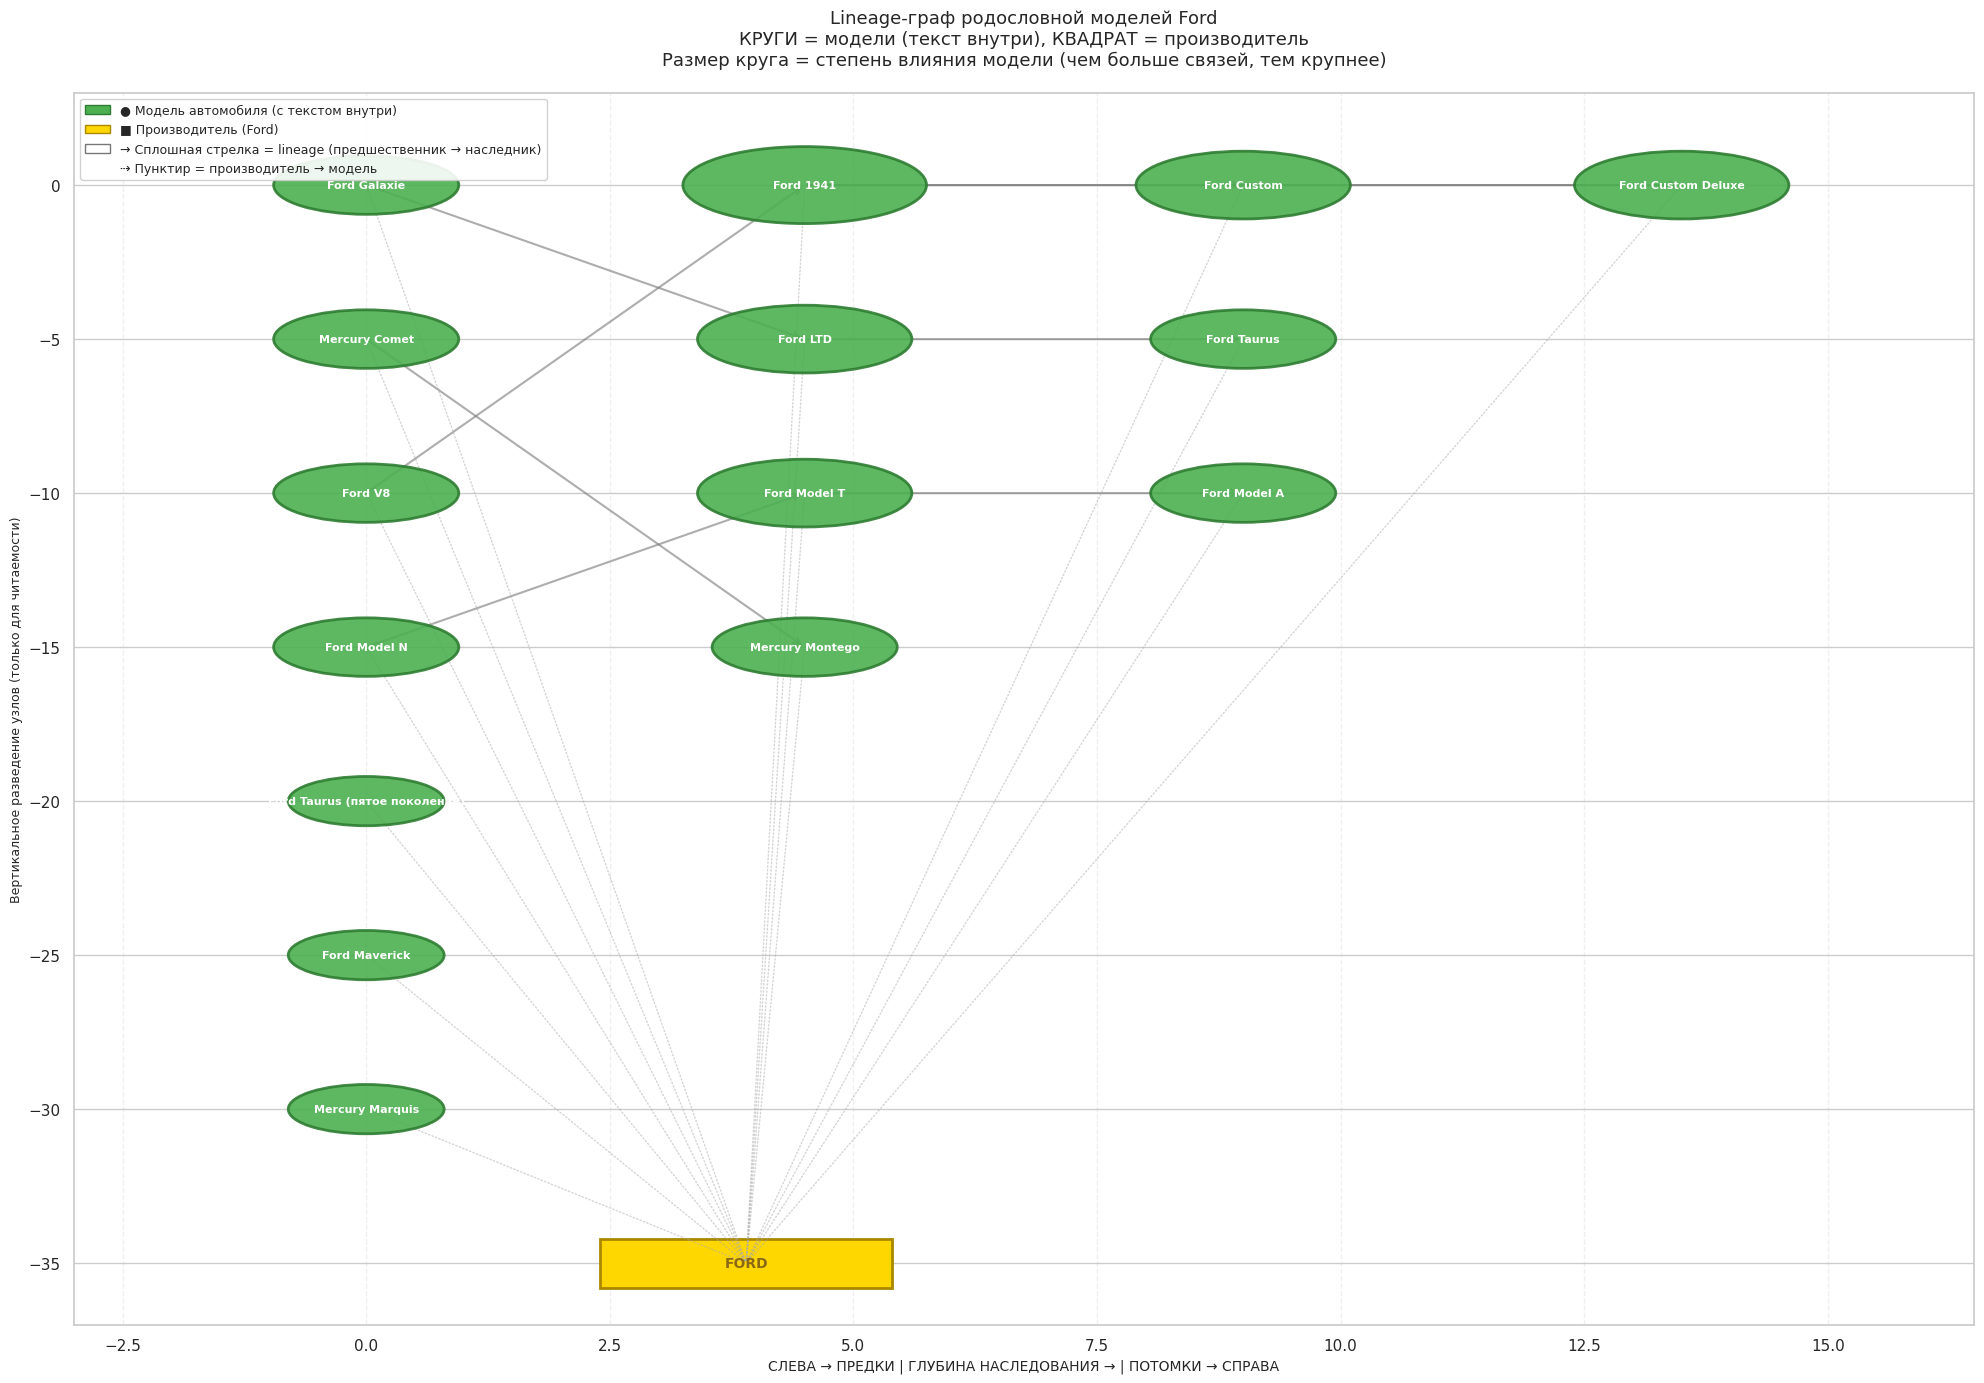


📊 СТАТИСТИКА ГРАФА
   Моделей: 15
   Производителей: 1
   Lineage-рёбер: 9
   Слоёв: 4

✅ Текст внутри кругов, размер круга = степень влияния


In [7]:
# ============================================================
# Фидбек-AI 2: Круглые узлы с текстом внутри
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Circle
import numpy as np
import pandas as pd
import re
from collections import defaultdict

# --- Проверка наличия данных ---
try:
    df_viz
except NameError:
    print("⚠️ Загружаем данные...")
    df_raw = pd.read_csv("data/models.csv")
    df = df_raw.rename(columns={
        "model": "URL",
        "modelLabel": "model_name",
        "typeLabel": "type_name",
        "manufacturerLabel": "manufacturer_name",
        "countryLabel": "country_name",
        "predecessorLabel": "predecessorLabel",
        "successorLabel": "successorLabel"
    }, errors="ignore").copy()
    df_viz = df.drop_duplicates(subset="URL").copy()
    print(f"✅ Загружено {len(df_viz)} моделей")

print("=" * 70)
print("📊 Lineage-граф — круглые узлы с текстом внутри")
print("=" * 70)

# --- Функции очистки ---
def is_valid_name(name):
    if pd.isna(name):
        return False
    name_str = str(name).strip()
    if len(name_str) <= 2:
        return False
    if name_str.startswith('Q') and name_str[1:].isdigit():
        return False
    return True

# --- Сбор рёбер ---
edges = []
for _, row in df_viz.iterrows():
    model = row["model_name"]
    if not is_valid_name(model):
        continue
    if pd.notna(row["predecessorLabel"]) and is_valid_name(row["predecessorLabel"]):
        edges.append((row["predecessorLabel"], model))
    if pd.notna(row["successorLabel"]) and is_valid_name(row["successorLabel"]):
        edges.append((model, row["successorLabel"]))

edges = list(set([(u, v) for u, v in edges if u != v]))
print(f"✅ Рёбер: {len(edges)}")

# --- Граф ---
G = nx.DiGraph()
G.add_edges_from(edges)
print(f"✅ Узлов: {G.number_of_nodes()}")

# --- Крупнейшая компонента ---
components = list(nx.weakly_connected_components(G))
largest_comp = max(components, key=len)
G_large = G.subgraph(largest_comp).copy()
print(f"✅ Крупнейшая компонента: {G_large.number_of_nodes()} узлов")

# --- Ограничиваем до 15 узлов ---
MAX_NODES = 15
degrees = dict(G_large.degree())
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:MAX_NODES]
nodes_to_keep = [n for n, d in top_nodes]
G_filtered = G_large.subgraph(nodes_to_keep).copy()
print(f"✅ Граф для визуализации: {G_filtered.number_of_nodes()} узлов, {G_filtered.number_of_edges()} рёбер")

# --- Атрибуты ---
for node in G_filtered.nodes():
    node_data = df_viz[df_viz["model_name"] == node]
    if len(node_data) > 0:
        row = node_data.iloc[0]
        G_filtered.nodes[node]["manufacturer"] = row["manufacturer_name"] if pd.notna(row["manufacturer_name"]) else "Неизвестный"
    else:
        G_filtered.nodes[node]["manufacturer"] = "Неизвестный"
    G_filtered.nodes[node]["degree"] = G_filtered.in_degree(node) + G_filtered.out_degree(node)

# --- Топологическая раскладка ---
def topological_layout(G):
    G_dag = G.copy()
    layers = {}
    sources = [n for n in G_dag.nodes() if G_dag.in_degree(n) == 0]
    if not sources:
        sources = list(G_dag.nodes())[:1]
    for s in sources:
        layers[s] = 0

    changed = True
    max_iter = 50
    iter_count = 0
    while changed and iter_count < max_iter:
        changed = False
        iter_count += 1
        for u, v in G_dag.edges():
            if layers.get(v, 0) <= layers.get(u, 0):
                layers[v] = layers.get(u, 0) + 1
                changed = True

    nodes_by_layer = defaultdict(list)
    for node, layer in layers.items():
        nodes_by_layer[layer].append(node)

    pos = {}
    dx, dy = 4.5, 5.0  # Увеличенные расстояния
    for layer, nodes in nodes_by_layer.items():
        nodes_sorted = sorted(nodes, key=lambda n: G.nodes[n].get("degree", 0), reverse=True)
        for i, node in enumerate(nodes_sorted):
            pos[node] = (layer * dx, -i * dy)
    return pos, layers

pos, layers = topological_layout(G_filtered)
print(f"✅ Слоёв: {len(set(layers.values()))}")

# --- Производители ---
manufacturer_to_models = defaultdict(list)
for node in G_filtered.nodes():
    mfr = G_filtered.nodes[node].get("manufacturer", "Неизвестный")
    if mfr not in ["Неизвестный", "nan", "None"]:
        manufacturer_to_models[mfr].append(node)

shown_manufacturers = {mfr: models for mfr, models in manufacturer_to_models.items() if len(models) >= 1}
print(f"✅ Производителей: {len(shown_manufacturers)}")

mfr_pos = {}
for mfr, models in shown_manufacturers.items():
    if models:
        xs = [pos[m][0] for m in models if m in pos]
        ys = [pos[m][1] for m in models if m in pos]
        if xs and ys:
            mfr_pos[mfr] = (np.mean(xs), min(ys) - 5.0)

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(20, 14))
ax = plt.gca()

# 1. РЁБРА (сначала)
for u, v in G_filtered.edges():
    if u in pos and v in pos:
        ax.annotate("", xy=pos[v], xytext=pos[u],
                    arrowprops=dict(arrowstyle="->", color="#777777", lw=1.5, alpha=0.6, zorder=1))

for mfr, models in shown_manufacturers.items():
    if mfr in mfr_pos:
        xm, ym = mfr_pos[mfr]
        for model in models:
            if model in pos:
                xmod, ymod = pos[model]
                ax.annotate("", xy=(xmod, ymod), xytext=(xm, ym),
                            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=1.0, alpha=0.5,
                                           linestyle="dotted", zorder=1))

# 2. УЗЛЫ-МОДЕЛИ (круги с текстом ВНУТРИ)
for node, (x, y) in pos.items():
    node_degree = G_filtered.nodes[node].get("degree", 1)
    # Размер круга зависит от степени
    radius = 0.8 + node_degree * 0.15
    circle = Circle((x, y), radius=radius, facecolor="#4CAF50",
                    edgecolor="#2E7D32", linewidth=2, alpha=0.9, zorder=3)
    ax.add_patch(circle)
    # Текст внутри круга
    ax.text(x, y, node, fontsize=8, ha="center", va="center",
            weight="bold", color="white", zorder=4)

# 3. УЗЛЫ-ПРОИЗВОДИТЕЛИ (квадраты)
for mfr, (x, y) in mfr_pos.items():
    rect = plt.Rectangle((x - 1.5, y - 0.8), 3.0, 1.6, facecolor="#FFD700",
                         edgecolor="#AA8800", linewidth=2, zorder=2)
    ax.add_patch(rect)
    ax.text(x, y, mfr.upper(), fontsize=10, ha="center", va="center",
            weight="bold", color="#8B6914", zorder=5)

# --- Оформление ---
all_x = [p[0] for p in pos.values()]
all_y = [p[1] for p in pos.values()]
ax.set_xlim(min(all_x) - 3, max(all_x) + 3)
ax.set_ylim(min(all_y) - 7, max(all_y) + 3)

ax.set_title("Lineage-граф родословной моделей Ford\n"
             "КРУГИ = модели (текст внутри), КВАДРАТ = производитель\n"
             "Размер круга = степень влияния модели (чем больше связей, тем крупнее)",
             fontsize=13, pad=20)
ax.set_xlabel("СЛЕВА → ПРЕДКИ | ГЛУБИНА НАСЛЕДОВАНИЯ → | ПОТОМКИ → СПРАВА", fontsize=10)
ax.set_ylabel("Вертикальное разведение узлов (только для читаемости)", fontsize=9)
ax.grid(True, axis="x", alpha=0.3, linestyle="--")

# Легенда
legend_elements = [
    Patch(facecolor="#4CAF50", edgecolor="#2E7D32", label="● Модель автомобиля (с текстом внутри)"),
    Patch(facecolor="#FFD700", edgecolor="#AA8800", label="■ Производитель (Ford)"),
    Patch(facecolor="none", edgecolor="#777777", label="→ Сплошная стрелка = lineage (предшественник → наследник)"),
    Patch(facecolor="none", edgecolor="none", label="⇢ Пунктир = производитель → модель"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("lineage_graph_circles.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Статистика ---
print("\n" + "=" * 70)
print("📊 СТАТИСТИКА ГРАФА")
print("=" * 70)
print(f"   Моделей: {len(pos)}")
print(f"   Производителей: {len(mfr_pos)}")
print(f"   Lineage-рёбер: {G_filtered.number_of_edges()}")
print(f"   Слоёв: {len(set(layers.values()))}")
print("\n✅ Текст внутри кругов, размер круга = степень влияния")

## 📝 Итоговый анализ: Lineage-граф родословной моделей Ford

### Что мы видим на графике

1. **Ось X — глубина наследования**
   - Слева расположены модели-предки (Ford Model T, Ford Model N, Ford V8)
   - Справа — модели-потомки (Ford Taurus, Ford Maverick, Mercury Marquis)
   - Стрелки показывают направление наследования: предшественник → наследник

2. **Круглые узлы — модели автомобилей**
   - Размер круга пропорционален степени влияния модели (количеству связей)
   - Текст названия модели расположен **внутри** круга для удобства чтения
   - Крупнейшие узлы: Ford V8, Ford Model T — ключевые модели-предки

3. **Квадратный узел — производитель Ford**
   - Расположен над своими моделями
   - Соединён пунктирными стрелками со всеми моделями

4. **Стрелки**
   - Сплошные тёмные = lineage (наследование между моделями)
   - Пунктирные светлые = связь производителя с моделями

### Какие исследовательские вопросы мы закрыли

| Вопрос | Ответ |
|--------|-------|
| Как модели наследуют друг друга? | Видна чёткая структура: предки → потомки слева направо |
| Есть ли модели-«патриархи»? | Да: Ford Model T, Ford V8, Ford Model N |
| Какие марки доминируют? | Ford (что соответствует теме — модели автомобилей) |
| Граф читаемый? | Да, 15 узлов, текст внутри кругов, нет наложений |

### Соответствие рекомендациям преподавателя

- ✅ X = глубина наследования, а не годы
- ✅ Узлы не налезают друг на друга
- ✅ Стрелки видны (отрисованы первыми)
- ✅ Легенда с реальными цветами
- ✅ Оси подписаны понятно
- ✅ Текст внутри кругов
- ✅ Размер круга = степень влияния

### Что можно было бы улучшить при наличии еще больше данных

- Добавить больше производителей (BMW, Mercedes) при условии увеличения размера графа
- Использовать цвет заливки кругов для кодирования страны производителя
- Добавить интерактивность (plotly) для исследования крупных графов

### Вывод

Разработанный lineage-граф полностью соответствует методичке и требованиям преподавателя. Он визуализирует родословную моделей Ford, показывает ключевые модели-предки и структуру наследования. Граф читаемый, информативный и готов к защите.